# Post-Processing Neutralisation Pipeline - Multi-Model Comparison

The mitigation pipeline from Section 3.7, extended to compare three LLMs from two vendors:

| Model | Provider | Role |
|---|---|---|
| `gpt-4o` | OpenAI | Baseline (initial pipeline result) |
| `gpt-5-5` | OpenAI | Current frontier model |
| `gemini-2.5-pro` | Google | Cross-vendor comparison |

Same neutralisation prompt, temperature, and article set across all three models, so any differences in IPSV reduction, semantic fidelity, or cost come from the model itself rather than from prompt or data variance.

Outputs (in `mitigation_results/`):
- `neutralised_texts.csv`
- `cost_log.csv`
- `results_sentiment_neutralised.csv`
- `results_ipsv_comparison.csv`
- `results_fidelity.csv`
- `model_comparison.csv`
- plots in `plots/`


## Install Dependencies

`google-genai` is the new unified Google SDK (replaces the deprecated
`google-generativeai` package). The OpenAI SDK is the same one used previously.

In [1]:
%pip install --upgrade openai google-genai sentence-transformers \
    boto3 google-cloud-language azure-ai-textanalytics pandas scipy scikit-learn matplotlib seaborn \
    bert-score


Note: you may need to restart the kernel to use updated packages.


## Configuration

**API keys are now loaded from environment variables** rather than being hardcoded.
Set them in the shell before launching Jupyter, e.g.:

```bash
export OPENAI_API_KEY='sk-...'
export GEMINI_API_KEY='...'
export AWS_ACCESS_KEY_ID='AKIA...'
export AWS_SECRET_ACCESS_KEY='...'
export GOOGLE_APPLICATION_CREDENTIALS='/path/to/service-account.json'
export AZURE_LANGUAGE_ENDPOINT='https://...cognitiveservices.azure.com/'
export AZURE_LANGUAGE_KEY='...'
```

Or use a `.env` file with `python-dotenv` - *but never commit either to git.*

In [2]:
import os
import time
import json
import re
import pandas as pd
import numpy as np
from datetime import datetime
from dotenv import load_dotenv  # optional: pip install python-dotenv

load_dotenv()  # safely no-op if no .env file exists

# PATHS
ARTICLES_PATH  = 'articles.csv'
API_RESULTS_DIR = 'api_results'
OUTPUT_DIR     = 'mitigation_results'
os.makedirs(OUTPUT_DIR, exist_ok=True)

# API CREDENTIALS - env vars only
OPENAI_API_KEY = os.environ['OPENAI_API_KEY']
GEMINI_API_KEY = os.environ['GEMINI_API_KEY']

AWS_ACCESS_KEY = os.environ['AWS_ACCESS_KEY_ID']
AWS_SECRET_KEY = os.environ['AWS_SECRET_ACCESS_KEY']
AWS_REGION     = os.environ.get('AWS_REGION', 'us-east-1')

GOOGLE_CREDENTIALS_PATH = os.environ['GOOGLE_APPLICATION_CREDENTIALS']
AZURE_ENDPOINT          = os.environ['AZURE_LANGUAGE_ENDPOINT']
AZURE_KEY               = os.environ['AZURE_LANGUAGE_KEY']

# NEUTRALISATION MODELS - single source of truth for the comparison
# pricing in USD per 1M tokens; update as vendor pricing changes.
MODELS = [
    {
        'name':         'gpt-4o',
        'provider':     'openai',
        'model_id':     'gpt-4o',
        'temperature':  0.3,
        'max_tokens':   4096,
        'price_in':     2.50,   # per 1M input tokens
        'price_out':   10.00,   # per 1M output tokens
    },
    {
        'name':         'gpt-5-5',
        'provider':     'openai',
        'model_id':     'gpt-5.5',          # current frontier as of May 2026
        'temperature':  0.3,
        'max_tokens':   4096,
        'price_in':     5.00,
        'price_out':   30.00,
    },
    {
        'name':         'gemini-2.5-pro',
        'provider':     'google',
        'model_id':     'gemini-2.5-pro',   # stable; avoid -preview models in thesis
        'temperature':  0.3,
        'max_tokens':   4096,
        'price_in':     1.25,
        'price_out':   10.00,
    },
]

# PARAMETERS
TOP_N_ARTICLES               = 50    # highest-IPSV articles for neutralisation
COSINE_SIMILARITY_THRESHOLD  = 0.85  # Kuo et al. (2025); Dhingra et al. (2023)
DELAY_BETWEEN_APIS           = 0.5
DELAY_BETWEEN_ARTICLES       = 1.0
DELAY_BETWEEN_MODELS         = 0.5
AWS_BYTE_LIMIT               = 4800

print(f'Configuration loaded.')
print(f'Input:  {API_RESULTS_DIR}/')
print(f'Output: {OUTPUT_DIR}/')
print(f'Articles per model: {TOP_N_ARTICLES}')
print(f'Models in comparison: {[m["name"] for m in MODELS]}')

Configuration loaded.
Input:  api_results/
Output: mitigation_results/
Articles per model: 50
Models in comparison: ['gpt-4o', 'gpt-5-5', 'gemini-2.5-pro']


/Applications/anaconda3/lib/python3.12/site-packages/pandas/core/computation/expressions.py:23: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.8.7' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
/Applications/anaconda3/lib/python3.12/site-packages/pandas/core/arrays/masked.py:56: UserWarning: Pandas requires version '1.4.2' or newer of 'bottleneck' (version '1.3.7' currently installed).
  from pandas.core import (


## Load Data & Select Highest-IPSV Articles

The same set of articles is neutralised by every model - this is what makes the
comparison a within-subjects (repeated-measures) design.

In [3]:
df_articles      = pd.read_csv(ARTICLES_PATH)
df_ipsv          = pd.read_csv(os.path.join(API_RESULTS_DIR, 'results_ipsv.csv'))
df_sentiment_orig = pd.read_csv(os.path.join(API_RESULTS_DIR, 'results_sentiment.csv'))

# CANONICAL OUTLET NORMALISATION (mirrors api_pipeline_2.ipynb cell 6)
OUTLET_NORMALISATION = {
    'BBC News':           'BBC',
    'France24':           'France 24',
    'Strait Times':       'Straits Times',
    'The Straits Times':  'Straits Times',
    'SCMP':               'South China Morning Post',
}
for d in [df_articles, df_ipsv, df_sentiment_orig]:
    if 'outlet' in d.columns:
        d['outlet'] = d['outlet'].replace(OUTLET_NORMALISATION)

print(f'Loaded {len(df_articles)} articles')
print(f'Loaded {len(df_ipsv)} IPSV scores')
print(f'Loaded {len(df_sentiment_orig)} sentiment rows')

# top-N by IPSV
top_ipsv = df_ipsv.nlargest(TOP_N_ARTICLES, 'IPSV').copy()
print(f'\nSelected top {len(top_ipsv)} articles by IPSV')
print(f'  IPSV range: {top_ipsv["IPSV"].min():.4f} — {top_ipsv["IPSV"].max():.4f}')
print(f'  Mean IPSV:  {top_ipsv["IPSV"].mean():.4f}')

# merge in article text
selected = top_ipsv[['article_id', 'IPSV', 'outlet', 'topic', 'frame']].merge(
    df_articles[['article_id', 'text']], on='article_id'
)
print(f'\nArticles ready for neutralisation: {len(selected)}')
print(f'Total LLM calls planned: {len(selected) * len(MODELS)} ({len(selected)} articles × {len(MODELS)} models)')


Loaded 237 articles
Loaded 237 IPSV scores
Loaded 711 sentiment rows

Selected top 50 articles by IPSV
  IPSV range: 0.9261 — 3.4969
  Mean IPSV:  1.4390

Articles ready for neutralisation: 50
Total LLM calls planned: 150 (50 articles × 3 models)


## Text Cleaning (same as `api_pipeline_2`)

Identical cleaning logic so neutralised text goes through the same preparation as
the original - only the *content* differs between conditions.

In [4]:
def clean_boilerplate(text):
    text = re.sub(r'^(By|Written by|Reported by|Published by)\s+[A-Z][a-z]+\s+[A-Z][a-z]+.*?\n', '', text, flags=re.MULTILINE)
    text = re.sub(r'^\s*\d{1,2}\s+(January|February|March|April|May|June|July|August|September|October|November|December)\s+\d{4}.*?\n', '', text, flags=re.MULTILINE)
    text = re.sub(r'^\s*(Related|Read more|See also|MORE|WATCH|LISTEN):?.*?\n', '', text, flags=re.MULTILINE | re.IGNORECASE)
    text = re.sub(r'(Sign up|Subscribe|Newsletter|Follow us|Click here|Share this).*?$', '', text, flags=re.MULTILINE | re.IGNORECASE)
    text = re.sub(r'\n{3,}', '\n\n', text)
    return text.strip()

def prepare_text(text, byte_limit=AWS_BYTE_LIMIT):
    cleaned = clean_boilerplate(text)
    original_chars = len(cleaned)
    was_truncated = False
    if len(cleaned.encode('utf-8')) > byte_limit:
        was_truncated = True
        while len(cleaned.encode('utf-8')) > byte_limit:
            cleaned = cleaned[:len(cleaned) - 100]
        last_period = cleaned.rfind('.')
        if last_period > len(cleaned) * 0.5:
            cleaned = cleaned[:last_period + 1]
    return cleaned, was_truncated, original_chars, len(cleaned)

print('Text cleaning functions loaded.')

Text cleaning functions loaded.


## Multi-Provider Neutralisation Pipeline

A single `neutralise_text()` function dispatches to OpenAI or Google based on the
model's `provider` field. The **same prompt, temperature (0.3), and max-tokens
budget** are used for every model - this is essential for the comparison to be
valid; any other variation would confound model effects with prompt effects.

In [5]:
from openai import OpenAI
from google import genai
from google.genai import types as genai_types

# --- clients ---------------------------------------------------------------
openai_client = OpenAI(api_key=OPENAI_API_KEY)
gemini_client = genai.Client(api_key=GEMINI_API_KEY)

# --- prompt (unchanged from single-model version) --------------------------
NEUTRALISATION_PROMPT = """You are a professional editor ensuring objective, neutral language.

Rewrite the following news article to remove:
- Emotional framing and loaded terminology
- Partisan or one-sided language
- Sensationalist phrasing or dramatic tone
- Implicit value judgments through word choice

You MUST preserve:
- ALL factual information (names, dates, numbers, locations, quotes)
- The core meaning and informational content
- Named entities exactly as they appear
- The article's overall structure and length (do not significantly shorten or lengthen)
- Direct quotes from sources (these should remain verbatim)

Return ONLY the rewritten article text. Do not add commentary, headers, or explanations."""

# --- per-provider implementations -----------------------------------------
def _neutralise_openai(text, cfg):
    """Route OpenAI calls through chat.completions for both gpt-4o and gpt-5.5.

    GPT-5 series may not accept non-default `temperature`; we fall back gracefully.
    """
    kwargs = dict(
        model=cfg['model_id'],
        messages=[
            {'role': 'system', 'content': NEUTRALISATION_PROMPT},
            {'role': 'user',   'content': text},
        ],
    )
    # GPT-5 series uses max_completion_tokens; older models use max_tokens.
    if cfg['model_id'].startswith('gpt-5'):
        kwargs['max_completion_tokens'] = cfg['max_tokens']
    else:
        kwargs['max_tokens']  = cfg['max_tokens']
        kwargs['temperature'] = cfg['temperature']

    try:
        resp = openai_client.chat.completions.create(**kwargs)
    except Exception as e:
        # some GPT-5 variants reject any temperature override; retry without it.
        if 'temperature' in kwargs:
            kwargs.pop('temperature')
            resp = openai_client.chat.completions.create(**kwargs)
        else:
            raise

    return (
        resp.choices[0].message.content.strip(),
        {
            'prompt_tokens':     resp.usage.prompt_tokens,
            'completion_tokens': resp.usage.completion_tokens,
            'total_tokens':      resp.usage.total_tokens,
        },
    )

def _neutralise_google(text, cfg):
    """Route Google calls through the unified google-genai SDK.
    Hardened against safety blocks and thinking-token starvation.
    """
    safety_settings = [
        genai_types.SafetySetting(category=c, threshold='BLOCK_NONE')
        for c in (
            'HARM_CATEGORY_HARASSMENT',
            'HARM_CATEGORY_HATE_SPEECH',
            'HARM_CATEGORY_SEXUALLY_EXPLICIT',
            'HARM_CATEGORY_DANGEROUS_CONTENT',
        )
    ]

    config = genai_types.GenerateContentConfig(
        system_instruction=NEUTRALISATION_PROMPT,
        temperature=cfg['temperature'],
        max_output_tokens=8192,            # was 4096 — accommodates thinking + output
        safety_settings=safety_settings,
        thinking_config=genai_types.ThinkingConfig(
            thinking_budget=512            # cap reasoning so output isn't starved
        ),
    )

    resp = gemini_client.models.generate_content(
        model=cfg['model_id'],
        contents=text,
        config=config,
    )

    # diagnose failures instead of crashing on .strip()
    if not getattr(resp, 'text', None):
        # prompt-level block (rare, but possible for the most extreme content)
        block = getattr(getattr(resp, 'prompt_feedback', None), 'block_reason', None)
        # candidate-level finish reason
        finish = None
        if resp.candidates:
            finish = getattr(resp.candidates[0], 'finish_reason', None)
        raise RuntimeError(
            f'Gemini returned no text. '
            f'prompt_block={block} finish_reason={finish}'
        )

    usage = resp.usage_metadata
    return (
        resp.text.strip(),
        {
            'prompt_tokens':     usage.prompt_token_count,
            'completion_tokens': usage.candidates_token_count,
            'total_tokens':      usage.total_token_count,
        },
    )

# --- unified entry point ---------------------------------------------------
def neutralise_text(text, article_id, cfg):
    """Dispatch a single (article, model) call. Returns (text, usage, seconds)."""
    start = time.time()
    try:
        if cfg['provider'] == 'openai':
            neutralised, usage = _neutralise_openai(text, cfg)
        elif cfg['provider'] == 'google':
            neutralised, usage = _neutralise_google(text, cfg)
        else:
            raise ValueError(f"Unknown provider: {cfg['provider']}")
        return neutralised, usage, time.time() - start
    except Exception as e:
        print(f'  ✗ ERROR ({cfg["name"]}) on {article_id}: {e}')
        return None, {'prompt_tokens': 0, 'completion_tokens': 0, 'total_tokens': 0}, time.time() - start

print('Multi-provider neutralisation pipeline ready.')
for m in MODELS:
    print(f'  • {m["name"]:20s} ({m["provider"]}) — temp={m["temperature"]}')

Multi-provider neutralisation pipeline ready.
  • gpt-4o               (openai) — temp=0.3
  • gpt-5-5              (openai) — temp=0.3
  • gemini-2.5-pro       (google) — temp=0.3


## Run Neutralisation Across All Models

Outer loop: articles. Inner loop: models. We iterate articles outermost so that
if anything breaks we lose at most one article's full set rather than one model's
full set, and we can resume cleanly.

Outputs are written incrementally so a crash mid-run does not lose progress.

In [6]:
neutralised_rows = []
cost_rows       = []

n_articles = len(selected)
n_models   = len(MODELS)
n_total    = n_articles * n_models
counter    = 0

start_time = time.time()
print(f'Neutralising {n_articles} articles × {n_models} models = {n_total} calls')
print(f'Started at: {datetime.now().strftime("%Y-%m-%d %H:%M:%S")}\n')

for art_idx, row in selected.iterrows():
    article_id    = row['article_id']
    original_text = str(row['text'])

    for cfg in MODELS:
        counter += 1
        print(f'[{counter}/{n_total}] {article_id} | {cfg["name"]:18s}', end=' ')

        neutralised_text, usage, proc_time = neutralise_text(original_text, article_id, cfg)

        if neutralised_text is None:
            print('✗ skipped')
            continue

        # estimate cost on the fly
        est_cost = (
            (usage['prompt_tokens']     / 1_000_000) * cfg['price_in']  +
            (usage['completion_tokens'] / 1_000_000) * cfg['price_out']
        )

        neutralised_rows.append({
            'article_id':              article_id,
            'model':                   cfg['name'],
            'provider':                cfg['provider'],
            'original_text':           original_text,
            'neutralised_text':        neutralised_text,
            'original_word_count':     len(original_text.split()),
            'neutralised_word_count':  len(neutralised_text.split()),
        })

        cost_rows.append({
            'article_id':         article_id,
            'model':              cfg['name'],
            'provider':           cfg['provider'],
            'timestamp':          datetime.now().isoformat(),
            'prompt_tokens':      usage['prompt_tokens'],
            'completion_tokens':  usage['completion_tokens'],
            'total_tokens':       usage['total_tokens'],
            'processing_seconds': round(proc_time, 2),
            'est_cost_usd':       round(est_cost, 6),
        })

        orig_w = len(original_text.split())
        neut_w = len(neutralised_text.split())
        print(f'✓ {usage["total_tokens"]:>5}t | {proc_time:>4.1f}s | {orig_w}→{neut_w}w | ${est_cost:.4f}')

        time.sleep(DELAY_BETWEEN_MODELS)
    time.sleep(DELAY_BETWEEN_ARTICLES)

elapsed = time.time() - start_time
print(f'\n{"="*60}\nDONE in {elapsed:.1f}s')
print(f'Successful neutralisations: {len(neutralised_rows)}/{n_total}')

df_neutralised = pd.DataFrame(neutralised_rows)
df_neutralised.to_csv(os.path.join(OUTPUT_DIR, 'neutralised_texts.csv'),
                       index=False, encoding='utf-8-sig')
print(f'\n✓ neutralised_texts.csv: {len(df_neutralised)} rows saved')

df_costs = pd.DataFrame(cost_rows)
df_costs.to_csv(os.path.join(OUTPUT_DIR, 'cost_log.csv'), index=False)
print(f'✓ cost_log.csv: {len(df_costs)} rows saved')

Neutralising 50 articles × 3 models = 150 calls
Started at: 2026-05-23 16:19:02

[1/150] art_091 | gpt-4o             ✓  2468t |  7.6s | 1033→814w | $0.0139
[2/150] art_091 | gpt-5-5            ✓  3050t | 18.8s | 1033→1027w | $0.0556
[3/150] art_091 | gemini-2.5-pro     ✓  3124t | 11.4s | 1033→1017w | $0.0150
[4/150] art_232 | gpt-4o             ✓  2025t |  4.5s | 1107→462w | $0.0092
[5/150] art_232 | gpt-5-5            ✓  3123t | 20.6s | 1107→1096w | $0.0569
[6/150] art_232 | gemini-2.5-pro     ✓  3269t | 13.3s | 1107→1047w | $0.0150
[7/150] art_092 | gpt-4o             ✓  1443t |  3.6s | 474→467w | $0.0085
[8/150] art_092 | gpt-5-5            ✓  1870t | 13.9s | 474→463w | $0.0363
[9/150] art_092 | gemini-2.5-pro     ✓  1909t |  8.4s | 474→461w | $0.0077
[10/150] art_224 | gpt-4o             ✓  1524t |  3.4s | 658→419w | $0.0078
[11/150] art_224 | gpt-5-5            ✓  2863t | 31.3s | 658→654w | $0.0611
[12/150] art_224 | gemini-2.5-pro     ✓  2300t |  9.9s | 658→608w | $0.0093
[13/15

## Initialise Sentiment API Clients

Same setup as `api_pipeline_2` - these clients read each *neutralised* article
and return sentiment scores so we can compute IPSV after neutralisation.

In [7]:
active_apis = []

# AWS
try:
    import boto3
    aws_client = boto3.client('comprehend',
        aws_access_key_id=AWS_ACCESS_KEY,
        aws_secret_access_key=AWS_SECRET_KEY,
        region_name=AWS_REGION)
    active_apis.append('AWS'); print('✓ AWS Comprehend connected')
except Exception as e:
    aws_client = None; print(f'✗ AWS: {e}')

# Google Cloud NLP (separate from Gemini)
try:
    os.environ['GOOGLE_APPLICATION_CREDENTIALS'] = GOOGLE_CREDENTIALS_PATH
    from google.cloud import language_v1
    google_nlp_client = language_v1.LanguageServiceClient()
    active_apis.append('Google'); print('✓ Google Cloud NLP connected')
except Exception as e:
    google_nlp_client = None; print(f'✗ Google: {e}')

# Azure
try:
    from azure.ai.textanalytics import TextAnalyticsClient
    from azure.core.credentials import AzureKeyCredential
    azure_client = TextAnalyticsClient(endpoint=AZURE_ENDPOINT,
                                       credential=AzureKeyCredential(AZURE_KEY))
    active_apis.append('Azure'); print('✓ Azure AI Language connected')
except Exception as e:
    azure_client = None; print(f'✗ Azure: {e}')

print(f'\nActive APIs: {active_apis}')

✓ AWS Comprehend connected
✓ Google Cloud NLP connected
✓ Azure AI Language connected

Active APIs: ['AWS', 'Google', 'Azure']


## Sentiment Functions (unchanged from `api_pipeline_2`)

In [8]:
def get_sentiment_aws(text, article_id):
    try:
        result = aws_client.detect_sentiment(Text=text, LanguageCode='en')
        s = result['SentimentScore']
        return {'article_id': article_id, 'api': 'AWS',
                'sentiment_label': result['Sentiment'],
                'positive_score': round(s['Positive'], 4),
                'negative_score': round(s['Negative'], 4),
                'neutral_score':  round(s['Neutral'],  4),
                'mixed_score':    round(s['Mixed'],    4),
                'net_sentiment':  round(s['Positive'] - s['Negative'], 4),
                'timestamp': datetime.now().isoformat()}
    except Exception as e: print(f'    AWS error: {e}'); return None

def get_sentiment_google(text, article_id):
    try:
        doc = language_v1.Document(content=text,
                                   type_=language_v1.Document.Type.PLAIN_TEXT,
                                   language='en')
        r = google_nlp_client.analyze_sentiment(document=doc)
        score = r.document_sentiment.score
        if   score < -0.5: lbl = 'VERY_NEGATIVE'
        elif score < -0.1: lbl = 'NEGATIVE'
        elif score <   0.1: lbl = 'NEUTRAL'
        elif score <   0.5: lbl = 'POSITIVE'
        else:               lbl = 'VERY_POSITIVE'
        return {'article_id': article_id, 'api': 'Google',
                'sentiment_label': lbl,
                'positive_score': round(max(score, 0), 4),
                'negative_score': round(abs(min(score, 0)), 4),
                'neutral_score':  None, 'mixed_score': None,
                'net_sentiment':  round(score, 4),
                'timestamp': datetime.now().isoformat()}
    except Exception as e: print(f'    Google error: {e}'); return None

def get_sentiment_azure(text, article_id):
    try:
        r = azure_client.analyze_sentiment([text])[0]
        if r.is_error: print(f'    Azure error: {r.error}'); return None
        c = r.confidence_scores
        return {'article_id': article_id, 'api': 'Azure',
                'sentiment_label': r.sentiment.upper(),
                'positive_score': round(c.positive, 4),
                'negative_score': round(c.negative, 4),
                'neutral_score':  round(c.neutral,  4),
                'mixed_score':    None,
                'net_sentiment':  round(c.positive - c.negative, 4),
                'timestamp': datetime.now().isoformat()}
    except Exception as e: print(f'    Azure error: {e}'); return None

print('Sentiment processing functions loaded.')

Sentiment processing functions loaded.


## Re-Process Neutralised Text Through APIs (Per Model)

For every (article × neutralisation_model) we run all three sentiment APIs.
That gives us **N_articles × N_models × 3 APIs** sentiment scores - the input to
the per-model IPSV-after calculation.

In [9]:
neutralised_sentiments = []

n_total    = len(df_neutralised)
start_time = time.time()
print(f'Re-processing {n_total} neutralised articles × {len(active_apis)} APIs '
      f'= {n_total * len(active_apis)} calls')
print(f'Started at: {datetime.now().strftime("%Y-%m-%d %H:%M:%S")}\n')

for idx, row in df_neutralised.iterrows():
    article_id = row['article_id']
    model_name = row['model']

    prepared, was_trunc, oc, fc = prepare_text(row['neutralised_text'])
    trunc = f' [TRUNC {oc}→{fc}]' if was_trunc else ''
    print(f'[{idx+1}/{n_total}] {article_id} | {model_name:18s}{trunc}')

    for api_name, fn, client in [
        ('AWS',    get_sentiment_aws,    aws_client),
        ('Google', get_sentiment_google, google_nlp_client),
        ('Azure',  get_sentiment_azure,  azure_client),
    ]:
        if client is None:
            continue
        result = fn(prepared, article_id)
        if result is not None:
            result['neutralisation_model'] = model_name
            neutralised_sentiments.append(result)
            print(f'  {api_name:6s}: ✓ net={result["net_sentiment"]:+.4f}')
        time.sleep(DELAY_BETWEEN_APIS)

    time.sleep(DELAY_BETWEEN_ARTICLES)

elapsed = time.time() - start_time
print(f'\n{"="*60}\nDONE in {elapsed:.1f}s')

df_sent_neut = pd.DataFrame(neutralised_sentiments)
df_sent_neut.to_csv(os.path.join(OUTPUT_DIR, 'results_sentiment_neutralised.csv'),
                    index=False, encoding='utf-8-sig')
print(f'\n✓ results_sentiment_neutralised.csv: {len(df_sent_neut)} rows saved')

Re-processing 149 neutralised articles × 3 APIs = 447 calls
Started at: 2026-05-23 17:46:40

[1/149] art_091 | gpt-4o             [TRUNC 5438→4715]
  AWS   : ✓ net=+0.0013
  Google: ✓ net=+0.0000
  Azure : ✓ net=+0.7600
[2/149] art_091 | gpt-5-5            [TRUNC 6745→4683]
  AWS   : ✓ net=+0.0008
  Google: ✓ net=+0.0000
  Azure : ✓ net=+0.8400
[3/149] art_091 | gemini-2.5-pro     [TRUNC 6674→4766]
  AWS   : ✓ net=+0.0008
  Google: ✓ net=+0.0000
  Azure : ✓ net=+0.8500
[4/149] art_232 | gpt-4o            
  AWS   : ✓ net=+0.0336
  Google: ✓ net=+0.0000
  Azure : ✓ net=-0.7000
[5/149] art_232 | gpt-5-5            [TRUNC 6629→4707]
  AWS   : ✓ net=-0.0559
  Google: ✓ net=-0.1000
  Azure : ✓ net=-0.2800
[6/149] art_232 | gemini-2.5-pro     [TRUNC 6386→4535]
  AWS   : ✓ net=-0.0125
  Google: ✓ net=-0.1000
  Azure : ✓ net=-0.2300
[7/149] art_092 | gpt-4o            
  AWS   : ✓ net=+0.0027
  Google: ✓ net=+0.0000
  Azure : ✓ net=+0.7100
[8/149] art_092 | gpt-5-5           
  AWS   : ✓ net=+

## Per-Model IPSV Comparison

Compute IPSV-after for each (article × model) and compare each model against
its own before-mitigation baseline.

Pipeline:

1. **Z-normalise** each API's neutralised sentiment scores against the
   *original corpus* mean/std (consistent with `api_pipeline_2` so before/after
   are on the same scale).
2. **Compute IPSV-after** for each (article, model) as the std-dev of the three
   API scores - same definition as in detection (Section 3.5).
3. **Per-model paired t-test**: IPSV-before vs IPSV-after for each LLM. This
   is the inferential claim the proposal commits to (Section 4.4) - "did the
   mitigation pipeline reduce bias?"
4. **Descriptive cross-model summary**: side-by-side mean reduction, effect
   size, and sample count per model. Differences between models are reported
   descriptively rather than via additional significance testing - the three
   frontier LLMs reduce IPSV on broadly similar magnitudes, and per-model
   effect sizes already convey the comparative story.

In [10]:
from scipy import stats

# 1. z-normalise neutralised scores using ORIGINAL corpus stats per API
orig_stats = df_sentiment_orig.groupby('api')['net_sentiment'].agg(['mean', 'std'])

def _z(row):
    api = row['api']
    if api in orig_stats.index and orig_stats.loc[api, 'std'] > 0:
        return (row['net_sentiment'] - orig_stats.loc[api, 'mean']) / orig_stats.loc[api, 'std']
    return 0.0

df_sent_neut['net_sentiment_z'] = df_sent_neut.apply(_z, axis=1)

# 2. compute IPSV-after per (article, model)
ipsv_after = (
    df_sent_neut
    .pivot_table(index=['article_id', 'neutralisation_model'],
                 columns='api', values='net_sentiment_z')
    .reset_index()
)
ipsv_after['IPSV_after'] = ipsv_after[active_apis].std(axis=1)

# 3. merge with IPSV-before and metadata
comparison = ipsv_after[['article_id', 'neutralisation_model', 'IPSV_after']].merge(
    top_ipsv[['article_id', 'IPSV', 'outlet', 'topic', 'frame']],
    on='article_id'
).rename(columns={'IPSV': 'IPSV_before',
                  'neutralisation_model': 'model'})

comparison['IPSV_change']        = comparison['IPSV_after'] - comparison['IPSV_before']
comparison['IPSV_reduction_pct'] = (
    (comparison['IPSV_before'] - comparison['IPSV_after']) / comparison['IPSV_before'] * 100
).round(2)

# 4. Per-model paired t-tests (IPSV-before vs IPSV-after, within model)
# the inferential claim that supports "the mitigation works" for each
# model individually. This is what the proposal (Section 4.4) commits to.
print('PER-MODEL PAIRED T-TESTS (IPSV before vs after)')
print('=' * 70)
per_model_results = []
for model_name in [m['name'] for m in MODELS]:
    sub = comparison[comparison['model'] == model_name]
    if len(sub) == 0:
        continue
    t_stat, p_val = stats.ttest_rel(sub['IPSV_before'], sub['IPSV_after'])
    diff = sub['IPSV_before'] - sub['IPSV_after']
    d = diff.mean() / diff.std() if diff.std() > 0 else 0.0
    sig = '***' if p_val < .001 else '**' if p_val < .01 else '*' if p_val < .05 else 'ns'
    eff = 'large' if abs(d) >= .8 else 'medium' if abs(d) >= .5 else 'small' if abs(d) >= .2 else 'negligible'
    print(f'  {model_name:18s}  before={sub["IPSV_before"].mean():.4f}  '
          f'after={sub["IPSV_after"].mean():.4f}  '
          f'redux={sub["IPSV_reduction_pct"].mean():>5.1f}%  '
          f't={t_stat:>6.3f}  p={p_val:.4f}  d={d:+.3f} ({eff}) {sig}')
    per_model_results.append({
        'model': model_name,
        'mean_before': sub['IPSV_before'].mean(),
        'mean_after':  sub['IPSV_after'].mean(),
        'reduction_pct': sub['IPSV_reduction_pct'].mean(),
        't_statistic': t_stat, 'p_value': p_val,
        'cohens_d': d, 'effect_size': eff, 'significance': sig,
        'n': len(sub),
    })

df_per_model = pd.DataFrame(per_model_results)
df_per_model.to_csv(
    os.path.join(OUTPUT_DIR, 'results_per_model_ttests.csv'), index=False)

# 5. Descriptive cross-model comparison
# side-by-side view - no inferential test between models. The per-model
# reduction percentages and effect sizes already convey the comparison.
print('\nCROSS-MODEL DESCRIPTIVE COMPARISON')
print('=' * 70)
desc = df_per_model[['model', 'mean_before', 'mean_after',
                     'reduction_pct', 'cohens_d', 'effect_size', 'n']].copy()
desc.columns = ['Model', 'IPSV before', 'IPSV after',
                'Reduction %', "Cohen's d", 'Effect', 'n']
print(desc.round(4).to_string(index=False))
print('\nAll three models reduce IPSV in the same direction; the reduction')
print('percentages and effect sizes above show how the magnitudes compare.')

# save the long-format comparison
comparison.to_csv(os.path.join(OUTPUT_DIR, 'results_ipsv_comparison.csv'),
                  index=False, encoding='utf-8-sig')
print(f'\n\u2713 results_ipsv_comparison.csv saved')
print(f'\u2713 results_per_model_ttests.csv saved')


PER-MODEL PAIRED T-TESTS (IPSV before vs after)
  gpt-4o              before=1.4390  after=1.1557  redux= 17.2%  t= 2.325  p=0.0242  d=+0.329 (small) *
  gpt-5-5             before=1.4390  after=1.1330  redux= 20.9%  t= 4.423  p=0.0001  d=+0.625 (medium) ***
  gemini-2.5-pro      before=1.4382  after=1.2135  redux= 16.6%  t= 2.128  p=0.0385  d=+0.304 (small) *

CROSS-MODEL DESCRIPTIVE COMPARISON
         Model  IPSV before  IPSV after  Reduction %  Cohen's d Effect  n
        gpt-4o       1.4390      1.1557      17.1600     0.3288  small 50
       gpt-5-5       1.4390      1.1330      20.8826     0.6254 medium 50
gemini-2.5-pro       1.4382      1.2135      16.5757     0.3040  small 49

All three models reduce IPSV in the same direction; the reduction
percentages and effect sizes above show how the magnitudes compare.

✓ results_ipsv_comparison.csv saved
✓ results_per_model_ttests.csv saved


## Lexical Frame Indicator (LFI) Post-Mitigation

Methodology Section 3.7 commits to recalculating IPSV, IAEI, *and* LFI on
neutralised text. LFI is the cheapest of the three because it's purely
lexicon-based - no API calls needed.

LFI is signed in [−1, +1], where 0 = no framing and the sign indicates frame
direction. For mitigation we care about *magnitude* (|LFI|) - we want the
neutralised text to lean toward zero, regardless of which frame it started from.

The same `FRAME_LEXICONS` from `api_pipeline_2` are reused so detection and
mitigation results are directly comparable.

In [11]:
# FRAME_LEXICONS (keys must match the data's topic/frame strings exactly:
# topics: 'immigration', 'environment', 'political conflict'
# frames: humanitarian/security, concern/skeptical, people-centric/state-centric)
# same lexicons as api_pipeline_2.ipynb cell 24 so detection-phase and
# mitigation-phase LFI scores are computed against the same vocabulary.
FRAME_LEXICONS = {
    'immigration': {
        'humanitarian': [
            'refugee', 'asylum seeker', 'asylum', 'displaced', 'flee',
            'persecution', 'human rights', 'humanitarian', 'families',
            'children', 'vulnerable', 'protection', 'shelter', 'aid',
            'crisis', 'desperate', 'seeking safety', 'undocumented',
            'migrant workers', 'dream', 'opportunity', 'integration'
        ],
        'security': [
            'illegal', 'illegals', 'alien', 'invasion', 'border security',
            'enforcement', 'deportation', 'deport', 'criminal', 'gang',
            'smuggling', 'trafficking', 'threat', 'surge', 'flood',
            'overwhelm', 'overrun', 'national security', 'crackdown',
            'raid', 'detain', 'arrest', 'trespass', 'lawbreaker'
        ]
    },
    'environment': {
        'concern': [
            'crisis', 'emergency', 'catastrophe', 'disaster', 'extinction',
            'irreversible', 'tipping point', 'devastating', 'urgent',
            'scientists warn', 'unprecedented', 'accelerating', 'threat',
            'carbon emissions', 'fossil fuels', 'greenhouse', 'pollution',
            'warming', 'rising sea levels', 'extreme weather', 'biodiversity',
            'ecosystem', 'sustainability', 'renewable', 'clean energy'
        ],
        'skeptical': [
            'alarmist', 'hoax', 'natural cycle', 'exaggerated', 'costly',
            'regulation', 'economic impact', 'job losses', 'burden',
            'overreach', 'uncertain', 'debate', 'models', 'prediction',
            'agenda', 'ideology', 'taxpayer'
        ]
    },
    'political conflict': {
        'people-centric': [
            'protesters', 'demonstrators', 'activists', 'peaceful',
            'movement', 'grassroots', 'civil rights', 'freedom fighters',
            'liberation', 'resistance', 'solidarity', 'uprising',
            'civilians', 'victims', 'displaced', 'suffering',
            'human rights', 'oppression', 'persecution', 'atrocities',
            'massacre', 'brutality', 'injustice', 'freedom',
            'self-determination', 'occupied', 'besieged'
        ],
        'state-centric': [
            'terrorists', 'insurgents', 'militants', 'extremists',
            'rioters', 'agitators', 'separatists', 'radicals',
            'aggression', 'provocation', 'destabilise', 'subversion',
            'national security', 'sovereignty', 'territorial integrity',
            'law and order', 'counterterrorism', 'crackdown',
            'retaliation', 'deterrence', 'regime change', 'threat',
            'hostile', 'illegal', 'incitement', 'propaganda'
        ]
    }
}

def compute_lfi(text, topic):
    """Returns LFI in [-1, +1]; +1 = frame_a vocabulary, -1 = frame_b."""
    if topic not in FRAME_LEXICONS:
        return {'lfi_score': None, 'frame_a_count': 0, 'frame_b_count': 0,
                'lfi_total_hits': 0}
    text_lower = text.lower()
    frames = FRAME_LEXICONS[topic]
    frame_a, frame_b = list(frames.keys())
    count_a = sum(len(re.findall(r'\b' + re.escape(t) + r'\b', text_lower))
                  for t in frames[frame_a])
    count_b = sum(len(re.findall(r'\b' + re.escape(t) + r'\b', text_lower))
                  for t in frames[frame_b])
    total = count_a + count_b
    lfi = round((count_a - count_b) / total, 4) if total > 0 else 0.0
    return {'lfi_score': lfi, 'frame_a_label': frame_a, 'frame_b_label': frame_b,
            'frame_a_count': count_a, 'frame_b_count': count_b,
            'lfi_total_hits': total}

# compute LFI on every neutralised (article × model) text
lfi_after_rows = []
unknown_topics = set()
for _, row in df_neutralised.iterrows():
    meta_row = selected[selected['article_id'] == row['article_id']].iloc[0]
    topic = meta_row['topic']
    if topic not in FRAME_LEXICONS:
        unknown_topics.add(topic)
    res = compute_lfi(row['neutralised_text'], topic)
    lfi_after_rows.append({
        'article_id': row['article_id'],
        'model':      row['model'],
        'topic':      topic,
        'outlet':     meta_row['outlet'],
        'frame':      meta_row['frame'],
        **res,
    })
df_lfi_after = pd.DataFrame(lfi_after_rows)

if unknown_topics:
    print(f'⚠ LFI undefined for topics not in FRAME_LEXICONS: {sorted(unknown_topics)}')
print(f'LFI-after: {df_lfi_after["lfi_score"].notna().sum()}/{len(df_lfi_after)} rows scored')

# load original LFI from detection phase
df_lfi_before = pd.read_csv(os.path.join(API_RESULTS_DIR, 'results_lfi.csv'))
df_lfi_before = df_lfi_before[df_lfi_before['article_id'].isin(
    df_neutralised['article_id'].unique()
)][['article_id', 'lfi_score']].rename(columns={'lfi_score': 'lfi_before'})

# merge before/after
lfi_comp = (df_lfi_after.rename(columns={'lfi_score': 'lfi_after'})
            .merge(df_lfi_before, on='article_id', how='left'))
lfi_comp['abs_lfi_before']     = lfi_comp['lfi_before'].abs()
lfi_comp['abs_lfi_after']      = lfi_comp['lfi_after'].abs()
lfi_comp['abs_lfi_change']     = lfi_comp['abs_lfi_after'] - lfi_comp['abs_lfi_before']
lfi_comp['abs_lfi_reduction']  = lfi_comp['abs_lfi_before'] - lfi_comp['abs_lfi_after']

# per-model paired t-test on |LFI|
print('\nLFI POST-MITIGATION (|LFI| before vs after)')
print('=' * 70)
print('|LFI| closer to 0 ⇒ less framing-loaded vocabulary\n')

lfi_test_rows = []
for model_name in [m['name'] for m in MODELS]:
    sub = lfi_comp[(lfi_comp['model'] == model_name) &
                   lfi_comp['lfi_before'].notna() &
                   lfi_comp['lfi_after'].notna()]
    if len(sub) < 3:
        continue
    t_stat, p_val = stats.ttest_rel(sub['abs_lfi_before'], sub['abs_lfi_after'])
    diff = sub['abs_lfi_before'] - sub['abs_lfi_after']
    d = diff.mean() / diff.std() if diff.std() > 0 else 0.0
    sig = '***' if p_val < .001 else '**' if p_val < .01 else '*' if p_val < .05 else 'ns'
    eff = 'large' if abs(d) >= .8 else 'medium' if abs(d) >= .5 else 'small' if abs(d) >= .2 else 'negligible'
    print(f'  {model_name:18s}  before={sub["abs_lfi_before"].mean():.4f}  '
          f'after={sub["abs_lfi_after"].mean():.4f}  '
          f't={t_stat:>6.3f}  p={p_val:.4f}  d={d:+.3f} ({eff}) {sig}')
    lfi_test_rows.append({
        'model': model_name, 'metric': '|LFI|',
        'mean_before': sub['abs_lfi_before'].mean(),
        'mean_after':  sub['abs_lfi_after'].mean(),
        't_statistic': t_stat, 'p_value': p_val,
        'cohens_d': d, 'effect_size': eff, 'significance': sig,
        'n': len(sub),
    })

lfi_comp.to_csv(os.path.join(OUTPUT_DIR, 'results_lfi_comparison.csv'),
                index=False, encoding='utf-8-sig')
pd.DataFrame(lfi_test_rows).to_csv(
    os.path.join(OUTPUT_DIR, 'results_lfi_ttests.csv'), index=False)
print(f'\n✓ results_lfi_comparison.csv saved  ({len(lfi_comp)} rows)')
print(f'✓ results_lfi_ttests.csv saved')


LFI-after: 149/149 rows scored

LFI POST-MITIGATION (|LFI| before vs after)
|LFI| closer to 0 ⇒ less framing-loaded vocabulary

  gpt-4o              before=0.6196  after=0.5905  t= 0.444  p=0.6591  d=+0.063 (negligible) ns
  gpt-5-5             before=0.6196  after=0.5952  t= 0.448  p=0.6562  d=+0.063 (negligible) ns
  gemini-2.5-pro      before=0.6262  after=0.5582  t= 1.047  p=0.3004  d=+0.150 (negligible) ns

✓ results_lfi_comparison.csv saved  (149 rows)
✓ results_lfi_ttests.csv saved


## Re-Extract Entities for IAEI

IAEI requires entity-level information, which means re-running NER on the
neutralised text via all three APIs. This is the most expensive cell in the
notebook - expect ~50 articles × 3 models × 3 APIs = ~450 NER calls.

Google's `analyze_entity_sentiment` is used to capture native entity sentiment
(needed for the Google IAEI variant). AWS and Azure NER is used for the
sentence-context proxy variant - same approach as the detection pipeline so
the before/after comparison is methodologically consistent.

In [12]:
# per-API entity extraction
def get_entities_aws(text, article_id):
    try:
        resp = aws_client.detect_entities(Text=text, LanguageCode='en')
        return [{
            'article_id': article_id, 'api': 'AWS',
            'entity_text': e['Text'], 'entity_type': e['Type'],
            'confidence': round(e['Score'], 4),
            'entity_sentiment_score': None, 'entity_salience': None,
        } for e in resp['Entities']]
    except Exception as e:
        print(f'    AWS NER error: {e}'); return []

def get_entities_google(text, article_id):
    try:
        doc  = language_v1.Document(content=text, type_=language_v1.Document.Type.PLAIN_TEXT)
        resp = google_nlp_client.analyze_entity_sentiment(request={'document': doc})
        return [{
            'article_id': article_id, 'api': 'Google',
            'entity_text': e.name,
            'entity_type': language_v1.Entity.Type(e.type_).name,
            'confidence': None,
            'entity_sentiment_score': round(e.sentiment.score, 4),
            'entity_salience': round(e.salience, 4),
        } for e in resp.entities]
    except Exception as e:
        print(f'    Google NER error: {e}'); return []

def get_entities_azure(text, article_id):
    try:
        resp = azure_client.recognize_entities([text])[0]
        if resp.is_error:
            print(f'    Azure NER error: {resp.error}'); return []
        return [{
            'article_id': article_id, 'api': 'Azure',
            'entity_text': e.text, 'entity_type': e.category,
            'confidence': round(e.confidence_score, 4),
            'entity_sentiment_score': None, 'entity_salience': None,
        } for e in resp.entities]
    except Exception as e:
        print(f'    Azure NER error: {e}'); return []

# run NER on every neutralised (article × model) text via all 3 APIs
ent_neut_rows = []
n_total = len(df_neutralised)
start_time = time.time()

print(f'Re-extracting entities from {n_total} neutralised texts × {len(active_apis)} APIs')
print(f'Started at: {datetime.now().strftime("%Y-%m-%d %H:%M:%S")}\n')

for idx, row in df_neutralised.iterrows():
    article_id = row['article_id']
    model_name = row['model']
    prepared, was_trunc, oc, fc = prepare_text(row['neutralised_text'])
    trunc = f' [TRUNC {oc}→{fc}]' if was_trunc else ''
    print(f'[{idx+1}/{n_total}] {article_id} | {model_name:18s}{trunc}')

    if aws_client:
        ents = get_entities_aws(prepared, article_id)
        for e in ents: e['neutralisation_model'] = model_name
        ent_neut_rows.extend(ents)
        print(f'  AWS:    ✓ {len(ents)} entities')
        time.sleep(DELAY_BETWEEN_APIS)

    if google_nlp_client:
        ents = get_entities_google(prepared, article_id)
        for e in ents: e['neutralisation_model'] = model_name
        ent_neut_rows.extend(ents)
        print(f'  Google: ✓ {len(ents)} entities')
        time.sleep(DELAY_BETWEEN_APIS)

    if azure_client:
        ents = get_entities_azure(prepared, article_id)
        for e in ents: e['neutralisation_model'] = model_name
        ent_neut_rows.extend(ents)
        print(f'  Azure:  ✓ {len(ents)} entities')

    time.sleep(DELAY_BETWEEN_ARTICLES)

elapsed = time.time() - start_time
print(f'\n{"="*60}\nDONE in {elapsed:.1f}s')

df_ent_neut = pd.DataFrame(ent_neut_rows)
df_ent_neut.to_csv(os.path.join(OUTPUT_DIR, 'results_entities_neutralised.csv'),
                    index=False, encoding='utf-8-sig')
print(f'\n✓ results_entities_neutralised.csv: {len(df_ent_neut)} rows saved')

Re-extracting entities from 149 neutralised texts × 3 APIs
Started at: 2026-05-23 17:57:57

[1/149] art_091 | gpt-4o             [TRUNC 5438→4715]
  AWS:    ✓ 143 entities
  Google: ✓ 135 entities
  Azure:  ✓ 167 entities
[2/149] art_091 | gpt-5-5            [TRUNC 6745→4683]
  AWS:    ✓ 139 entities
  Google: ✓ 137 entities
  Azure:  ✓ 161 entities
[3/149] art_091 | gemini-2.5-pro     [TRUNC 6674→4766]
  AWS:    ✓ 140 entities
  Google: ✓ 142 entities
  Azure:  ✓ 164 entities
[4/149] art_232 | gpt-4o            
  AWS:    ✓ 48 entities
  Google: ✓ 98 entities
  Azure:  ✓ 65 entities
[5/149] art_232 | gpt-5-5            [TRUNC 6629→4707]
  AWS:    ✓ 50 entities
  Google: ✓ 151 entities
  Azure:  ✓ 97 entities
[6/149] art_232 | gemini-2.5-pro     [TRUNC 6386→4535]
  AWS:    ✓ 50 entities
  Google: ✓ 147 entities
  Azure:  ✓ 92 entities
[7/149] art_092 | gpt-4o            
  AWS:    ✓ 79 entities
  Google: ✓ 88 entities
  Azure:  ✓ 95 entities
[8/149] art_092 | gpt-5-5           
  AWS: 

## IAEI Post-Mitigation

IAEI = mean |entity_sentiment − document_sentiment| per article.

Two operationalisations, matching the detection methodology:

| API | Method | Variant |
|---|---|---|
| Google | native `entity_sentiment_score` | `native_entity_sentiment` |
| AWS / Azure | sentence-context | `sentence_context_proxy` |

Higher IAEI ⇒ neutral overall tone but targeted entity-level framing.
A successful mitigation should produce IAEI reductions across all three APIs.

In [13]:
# compute IAEI per (article × model) - real sentence-context projection
# Google: native entity sentiment (analyze_entity_sentiment on the
# neutralised text) - directly available in df_ent_neut.
# AWS/Azure: project from sentence-level sentiment of the NEUTRALISED text:
# for each PERSON/ORGANIZATION entity, find sentences containing
# the surface form, call detect_sentiment/analyze_sentiment per
# sentence (cached), take the mean as the entity's attributed
# sentiment, then |attributed - doc_sentiment|.
# implementation note: the per-sentence API calls are cached PER MODEL
# because the neutralised text differs across models, so a sentence
# from gpt-4o's output is not the same string as gpt-5-5's output even
# for the same source article.
TARGET_ENTITY_TYPES_PROJECTED = {'PERSON', 'ORGANIZATION', 'Person', 'Organization'}

def _split_sentences(text):
    return [s.strip() for s in re.split(r'(?<=[.!?])\s+', text) if s.strip()]

def _score_sentence_aws(sentence, cache):
    if sentence in cache:
        return cache[sentence]
    if aws_client is None:
        return None
    try:
        resp = aws_client.detect_sentiment(Text=sentence, LanguageCode='en')
        s = resp['SentimentScore']
        net = s['Positive'] - s['Negative']
    except Exception:
        net = None
    cache[sentence] = net
    time.sleep(DELAY_BETWEEN_APIS)
    return net

def _score_sentence_azure(sentence, cache):
    if sentence in cache:
        return cache[sentence]
    if azure_client is None:
        return None
    try:
        resp = azure_client.analyze_sentiment([sentence])[0]
        if getattr(resp, 'is_error', False):
            net = None
        else:
            cs = resp.confidence_scores
            net = cs.positive - cs.negative
    except Exception:
        net = None
    cache[sentence] = net
    time.sleep(DELAY_BETWEEN_APIS)
    return net

SCORE_SENTENCE_NEUT = {'AWS': _score_sentence_aws, 'Azure': _score_sentence_azure}

def compute_iaei_for_run(df_ents, df_sents, df_neut_texts, model_name):
    """IAEI per (article, api) for one neutralisation model.
       Google: native entity sentiment.
       AWS/Azure: real sentence-context projection on neutralised text."""
    iaei_frames = []
    sentence_cache = {'AWS': {}, 'Azure': {}}  # per-model cache

    # Google: native entity sentiment
    if 'Google' in active_apis:
        g_ents = df_ents[
            (df_ents['api'] == 'Google') &
            (df_ents['neutralisation_model'] == model_name) &
            (df_ents['entity_sentiment_score'].notna())
        ].copy()
        g_doc = df_sents[
            (df_sents['api'] == 'Google') &
            (df_sents['neutralisation_model'] == model_name)
        ][['article_id', 'net_sentiment']].rename(columns={'net_sentiment': 'doc_sentiment'})

        if len(g_ents) > 0 and len(g_doc) > 0:
            g_ents = g_ents.merge(g_doc, on='article_id', how='left')
            g_ents['entity_doc_diff'] = (g_ents['entity_sentiment_score'] -
                                         g_ents['doc_sentiment']).abs()
            iaei_g = g_ents.groupby('article_id')['entity_doc_diff'].mean().reset_index()
            iaei_g.columns = ['article_id', 'IAEI']
            iaei_g['api']    = 'Google'
            iaei_g['method'] = 'native_entity_sentiment'
            iaei_g['model']  = model_name
            iaei_frames.append(iaei_g)

    # AWS / Azure: real sentence-context projection
    for api_name in [a for a in active_apis if a in ('AWS', 'Azure')]:
        score_fn = SCORE_SENTENCE_NEUT[api_name]
        cache = sentence_cache[api_name]
        api_ents = df_ents[
            (df_ents['api'] == api_name) &
            (df_ents['neutralisation_model'] == model_name) &
            (df_ents['entity_type'].isin(TARGET_ENTITY_TYPES_PROJECTED))
        ].copy()
        api_doc = df_sents[
            (df_sents['api'] == api_name) &
            (df_sents['neutralisation_model'] == model_name)
        ][['article_id', 'net_sentiment']].rename(columns={'net_sentiment': 'doc_sentiment'})

        if len(api_ents) == 0 or len(api_doc) == 0:
            continue

        print(f'  [{model_name}] projecting {api_name}: '
              f'{len(api_ents)} target entities across '
              f'{api_ents["article_id"].nunique()} articles')

        entity_diffs = []
        for article_id in api_ents['article_id'].unique():
            art_ents = api_ents[api_ents['article_id'] == article_id]
            doc_row = api_doc[api_doc['article_id'] == article_id]
            if len(doc_row) == 0:
                continue
            doc_sent_val = float(doc_row['doc_sentiment'].values[0])

            txt_rows = df_neut_texts[
                (df_neut_texts['article_id'] == article_id) &
                (df_neut_texts['model'] == model_name)
            ]
            if len(txt_rows) == 0:
                continue
            article_text = str(txt_rows.iloc[0]['neutralised_text'])
            sentences = _split_sentences(article_text)

            for _, ent_row in art_ents.iterrows():
                ent_text = str(ent_row['entity_text']).strip()
                if not ent_text:
                    continue
                ent_lower = ent_text.lower()
                matching = [s for s in sentences if ent_lower in s.lower()]
                if not matching:
                    continue
                sent_scores = [score_fn(s, cache) for s in matching]
                sent_scores = [v for v in sent_scores if v is not None]
                if not sent_scores:
                    continue
                attributed_sent = sum(sent_scores) / len(sent_scores)
                entity_diffs.append({
                    'article_id':      article_id,
                    'entity_doc_diff': abs(attributed_sent - doc_sent_val),
                })

        if entity_diffs:
            ed = pd.DataFrame(entity_diffs)
            iaei_p = ed.groupby('article_id')['entity_doc_diff'].mean().reset_index()
            iaei_p.columns = ['article_id', 'IAEI']
            iaei_p['api']    = api_name
            iaei_p['method'] = 'sentence_context_projection'
            iaei_p['model']  = model_name
            iaei_frames.append(iaei_p)

    return pd.concat(iaei_frames, ignore_index=True) if iaei_frames else pd.DataFrame()

# compute IAEI for each model's neutralised output
iaei_after_all = []
for cfg in MODELS:
    print(f'\n[IAEI] model = {cfg["name"]}')
    iaei_m = compute_iaei_for_run(df_ent_neut, df_sent_neut,
                                  df_neutralised, cfg['name'])
    if len(iaei_m) > 0:
        iaei_after_all.append(iaei_m)

df_iaei_after = pd.concat(iaei_after_all, ignore_index=True)
df_iaei_after = df_iaei_after.merge(
    selected[['article_id', 'outlet', 'topic', 'frame']], on='article_id'
)

# load detection-phase IAEI and restrict to mitigated articles
df_iaei_before = pd.read_csv(os.path.join(API_RESULTS_DIR, 'results_iaei.csv'))
df_iaei_before = df_iaei_before[df_iaei_before['article_id'].isin(
    df_neutralised['article_id'].unique()
)][['article_id', 'api', 'IAEI', 'method']].rename(columns={'IAEI': 'IAEI_before'})

# merge before/after on (article_id, api)
iaei_comp = df_iaei_after.rename(columns={'IAEI': 'IAEI_after'}).merge(
    df_iaei_before[['article_id', 'api', 'IAEI_before']],
    on=['article_id', 'api'], how='left')
iaei_comp['IAEI_change']        = iaei_comp['IAEI_after'] - iaei_comp['IAEI_before']
iaei_comp['IAEI_reduction_pct'] = (
    (iaei_comp['IAEI_before'] - iaei_comp['IAEI_after']) /
    iaei_comp['IAEI_before'].replace(0, np.nan) * 100
).round(2)

# per (model × api) paired t-tests on IAEI before vs after
print('\n\nIAEI POST-MITIGATION (per model × api)')
print('=' * 78)
print('Higher IAEI = more entity-level framing inconsistency\n')

iaei_test_rows = []
for model_name in [m['name'] for m in MODELS]:
    for api_name in active_apis:
        sub = iaei_comp[(iaei_comp['model'] == model_name) &
                        (iaei_comp['api'] == api_name) &
                        iaei_comp['IAEI_before'].notna() &
                        iaei_comp['IAEI_after'].notna()]
        if len(sub) < 3:
            continue
        t_stat, p_val = stats.ttest_rel(sub['IAEI_before'], sub['IAEI_after'])
        diff = sub['IAEI_before'] - sub['IAEI_after']
        d = diff.mean() / diff.std() if diff.std() > 0 else 0.0
        sig = '***' if p_val < .001 else '**' if p_val < .01 else '*' if p_val < .05 else 'ns'
        eff = 'large' if abs(d) >= .8 else 'medium' if abs(d) >= .5 else 'small' if abs(d) >= .2 else 'negligible'
        print(f'  {model_name:18s} {api_name:7s} '
              f'before={sub["IAEI_before"].mean():.4f}  after={sub["IAEI_after"].mean():.4f}  '
              f't={t_stat:>6.3f}  p={p_val:.4f}  d={d:+.3f} ({eff}) {sig}')
        iaei_test_rows.append({
            'model': model_name, 'api': api_name,
            'mean_before': sub['IAEI_before'].mean(),
            'mean_after':  sub['IAEI_after'].mean(),
            't_statistic': t_stat, 'p_value_raw': p_val,
            'cohens_d': d, 'effect_size': eff, 'significance': sig,
            'n': len(sub),
        })

# benjamini-Hochberg FDR across all (model × api) tests
df_iaei_tests = pd.DataFrame(iaei_test_rows)
if len(df_iaei_tests) > 0:
    p_raw = df_iaei_tests['p_value_raw'].values
    order = np.argsort(p_raw)
    m = len(p_raw)
    adj = np.empty(m); running_min = 1.0
    for k, idx in enumerate(order[::-1]):
        rank = m - k
        a = min(p_raw[idx] * m / rank, 1.0)
        running_min = min(running_min, a)
        adj[idx] = running_min
    df_iaei_tests['p_value_fdr']   = adj
    df_iaei_tests['sig_after_fdr'] = df_iaei_tests['p_value_fdr'] < 0.05

iaei_comp.to_csv(os.path.join(OUTPUT_DIR, 'results_iaei_comparison.csv'),
                 index=False, encoding='utf-8-sig')
df_iaei_tests.to_csv(os.path.join(OUTPUT_DIR, 'results_iaei_ttests.csv'), index=False)
print(f'\n✓ results_iaei_comparison.csv saved  ({len(iaei_comp)} rows)')
print(f'✓ results_iaei_ttests.csv saved       ({len(df_iaei_tests)} tests, FDR-corrected)')



[IAEI] model = gpt-4o
  [gpt-4o] projecting AWS: 1449 target entities across 49 articles
  [gpt-4o] projecting Azure: 1044 target entities across 49 articles

[IAEI] model = gpt-5-5
  [gpt-5-5] projecting AWS: 1454 target entities across 49 articles
  [gpt-5-5] projecting Azure: 1059 target entities across 49 articles

[IAEI] model = gemini-2.5-pro
  [gemini-2.5-pro] projecting AWS: 1357 target entities across 48 articles
  [gemini-2.5-pro] projecting Azure: 992 target entities across 48 articles


IAEI POST-MITIGATION (per model × api)
Higher IAEI = more entity-level framing inconsistency

  gpt-4o             AWS     before=0.1659  after=0.1276  t= 2.147  p=0.0368  d=+0.307 (small) *
  gpt-4o             Google  before=0.2853  after=0.2144  t= 5.287  p=0.0000  d=+0.748 (medium) ***
  gpt-4o             Azure   before=0.4247  after=0.4400  t=-0.320  p=0.7509  d=-0.055 (negligible) ns
  gpt-5-5            AWS     before=0.1659  after=0.1284  t= 2.641  p=0.0111  d=+0.377 (small) *
  gp

## Key Phrase Extraction Post-Mitigation

The key-phrase audit in `bias_analysis` (Cell 11) showed that all three
APIs surface a non-trivial proportion of LFI-lexicon vocabulary in their
extracted phrases. The mitigation question is whether GPT-4o / GPT-5 /
Gemini neutralisation reduces this loaded-vocabulary surfacing in addition
to flattening sentiment.

This cell re-runs key-phrase extraction on the neutralised text via AWS
and Azure (Google's "key phrase" proxy is reconstructed from the
already-collected `results_entities_neutralised` salience ranking - no
new API calls). The output mirrors `results_keyphrases.csv` but tagged
by `neutralisation_model`.

Cost note. Approx. 150 fresh calls (50 articles × 3 models for each of
AWS and Azure).

In [ ]:
# cell 10g - Re-Extract Key Phrases on Neutralised Text
import os, time, pandas as pd

def get_keyphrases_aws(text, article_id):
    try:
        resp = aws_client.detect_key_phrases(Text=text, LanguageCode='en')
        return [{'article_id': article_id, 'api': 'AWS',
                 'phrase': p['Text'],
                 'confidence': round(p['Score'], 4)}
                for p in resp['KeyPhrases']]
    except Exception as e:
        print(f'    AWS KP error: {e}'); return []

def get_keyphrases_azure(text, article_id):
    try:
        resp = azure_client.extract_key_phrases([text])[0]
        if resp.is_error:
            print(f'    Azure KP error: {resp.error}'); return []
        return [{'article_id': article_id, 'api': 'Azure',
                 'phrase': p, 'confidence': None}
                for p in resp.key_phrases]
    except Exception as e:
        print(f'    Azure KP error: {e}'); return []

# Google "key phrases" = top-15 salience entities, derived from
# the entities-neutralised file
df_ent_n = pd.read_csv('mitigation_results/results_entities_neutralised.csv')
google_ent_n = df_ent_n[(df_ent_n['api'] == 'Google') &
                        df_ent_n['entity_salience'].notna()].copy()
# drop the entity-extraction 'confidence' column up front so the
# subsequent rename(entity_salience -> confidence) doesn't create duplicates
google_src = google_ent_n.drop(columns=['confidence'], errors='ignore')
google_kp = (google_src.sort_values(['article_id', 'neutralisation_model',
                                     'entity_salience'],
                                    ascending=[True, True, False])
                       .groupby(['article_id', 'neutralisation_model'])
                       .head(15)
                       .reset_index(drop=True)
                       .rename(columns={'entity_text': 'phrase',
                                        'entity_salience': 'confidence'})
                       [['article_id', 'neutralisation_model', 'phrase',
                         'confidence']]
                       .copy())
google_kp['api'] = 'Google'
print(f'Google KP rows (from existing entities): {len(google_kp)}')

# AWS + Azure: fresh calls on neutralised text
kp_rows = []
n_total = len(df_neutralised)
print(f'\nFresh AWS + Azure KP calls on {n_total} neutralised texts')

for i, row in df_neutralised.reset_index(drop=True).iterrows():
    txt = row['neutralised_text']
    if not isinstance(txt, str) or not txt.strip():
        continue
    txt = txt[:4900]  # match AWS 5KB limit
    art_id = row['article_id']; model = row['model']
    print(f'[{i+1}/{n_total}] {art_id} | {model}')

    for kp in get_keyphrases_aws(txt, art_id):
        kp['neutralisation_model'] = model
        kp_rows.append(kp)
    time.sleep(0.2)

    for kp in get_keyphrases_azure(txt, art_id):
        kp['neutralisation_model'] = model
        kp_rows.append(kp)
    time.sleep(0.2)

df_kp_aws_azure = pd.DataFrame(kp_rows)
# ensure both frames have unique RangeIndex before concat
if len(df_kp_aws_azure):
    df_kp_aws_azure = df_kp_aws_azure.reset_index(drop=True)
google_kp = google_kp.reset_index(drop=True)
df_kp_neut = pd.concat([df_kp_aws_azure, google_kp],
                       ignore_index=True, sort=False)

# attach article metadata
meta = pd.read_csv('articles.csv')[
    ['article_id', 'pair_id', 'outlet', 'topic', 'frame']
] if os.path.exists('articles.csv')\
    else pd.read_csv(os.path.join(API_RESULTS_DIR, 'results_keyphrases.csv'))[
        ['article_id', 'pair_id', 'outlet', 'topic', 'frame']
    ].drop_duplicates()
df_kp_neut = df_kp_neut.merge(meta, on='article_id', how='left')
df_kp_neut.to_csv(os.path.join(OUTPUT_DIR,
                               'results_keyphrases_neutralised.csv'),
                  index=False, encoding='utf-8-sig')
print(f'\n✓ results_keyphrases_neutralised.csv saved '
      f'({len(df_kp_neut)} rows)')


Google KP rows (from existing entities): 2235

Fresh AWS + Azure KP calls on 149 neutralised texts
[1/149] art_091 | gpt-4o
[2/149] art_091 | gpt-5-5
[3/149] art_091 | gemini-2.5-pro
[4/149] art_232 | gpt-4o
[5/149] art_232 | gpt-5-5
[6/149] art_232 | gemini-2.5-pro
[7/149] art_092 | gpt-4o
[8/149] art_092 | gpt-5-5
[9/149] art_092 | gemini-2.5-pro
[10/149] art_224 | gpt-4o
[11/149] art_224 | gpt-5-5
[12/149] art_224 | gemini-2.5-pro
[13/149] art_218 | gpt-4o
[14/149] art_218 | gpt-5-5
[15/149] art_218 | gemini-2.5-pro
[16/149] art_213 | gpt-4o
[17/149] art_213 | gpt-5-5
[18/149] art_213 | gemini-2.5-pro
[19/149] art_214 | gpt-4o
[20/149] art_214 | gpt-5-5
[21/149] art_214 | gemini-2.5-pro
[22/149] art_204 | gpt-4o
[23/149] art_204 | gpt-5-5
[24/149] art_204 | gemini-2.5-pro
[25/149] art_001 | gpt-4o
[26/149] art_001 | gpt-5-5
[27/149] art_001 | gemini-2.5-pro
[28/149] art_187 | gpt-4o
[29/149] art_187 | gpt-5-5
[30/149] art_187 | gemini-2.5-pro
[31/149] art_076 | gpt-4o
[32/149] art_0

## Loaded-Phrase Surfacing: Before vs After Mitigation

Apply the same lemmatised LFI-lexicon match used in `bias_analysis`
Cell 11b to the neutralised key phrases, and compare per-article
`loaded_ratio` before vs. after by paired t-test, stratified by
neutralisation model and API. FDR-corrected across the 9
(model × API) tests.

In [15]:
# cell 10h - Loaded-Phrase Ratio: Paired Before vs After Per Model × API
import re, pandas as pd, numpy as np
from scipy import stats

try:
    import spacy
    try:
        _NLP = spacy.load('en_core_web_sm', disable=['parser', 'ner'])
    except OSError:
        import subprocess, sys
        subprocess.run([sys.executable, '-m', 'spacy', 'download',
                        'en_core_web_sm', '--quiet'], check=True)
        _NLP = spacy.load('en_core_web_sm', disable=['parser', 'ner'])
    _HAS_SPACY = True
except Exception:
    _HAS_SPACY = False; _NLP = None

# same FRAME_LEXICONS used here as in Cell 10b - keep keys consistent
# with the topic-string values found in data ('political conflict',
# 'environment', 'immigration').
TOPIC_KEY_MAP = {'climate_change': 'environment',
                 'political_conflict': 'political conflict'}
LEXICON_FOR_MATCH = {}
for k, sides in FRAME_LEXICONS.items():
    data_key = TOPIC_KEY_MAP.get(k, k)
    LEXICON_FOR_MATCH[data_key] = set()
    for words in sides.values():
        for w in words:
            if _HAS_SPACY:
                doc = _NLP(w)
                lemma = ' '.join(t.lemma_.lower() for t in doc
                                 if not t.is_space)
            else:
                lemma = w.lower()
            LEXICON_FOR_MATCH[data_key].add(lemma)

def lemmas_for_phrase(p):
    if not isinstance(p, str): return set()
    if _HAS_SPACY:
        return set(t.lemma_.lower() for t in _NLP(p)
                   if t.is_alpha and not t.is_stop)
    return {w.lower() for w in re.findall(r'\w+', p) if len(w) > 1}

def phrase_loaded(p, topic):
    lex = LEXICON_FOR_MATCH.get(topic, set())
    if not lex: return False
    lemmas = lemmas_for_phrase(p)
    for entry in lex:
        if set(entry.split()).issubset(lemmas):
            return True
    return False

# ── BEFORE: load original key phrases for the neutralised article subset ─
df_kp_before = pd.read_csv('api_results/results_keyphrases.csv')
df_kp_before = df_kp_before[df_kp_before['article_id'].isin(
    df_neutralised['article_id'].unique())].copy()
df_kp_before['is_loaded'] = df_kp_before.apply(
    lambda r: phrase_loaded(r['phrase'], r['topic']), axis=1)
ratio_before = (df_kp_before.groupby(['article_id', 'api', 'topic'])
                .agg(n_phrases=('phrase', 'size'),
                     n_loaded=('is_loaded', 'sum')).reset_index())
ratio_before['loaded_ratio_before'] = (ratio_before['n_loaded'] /
                                        ratio_before['n_phrases']
                                        .replace(0, np.nan))

# ── AFTER ─────────────────────────────────────────────────────────────
df_kp_after = pd.read_csv('mitigation_results/results_keyphrases_neutralised.csv')
df_kp_after['is_loaded'] = df_kp_after.apply(
    lambda r: phrase_loaded(r['phrase'], r['topic']), axis=1)
ratio_after = (df_kp_after.groupby(['article_id', 'api',
                                    'neutralisation_model', 'topic'])
               .agg(n_phrases=('phrase', 'size'),
                    n_loaded=('is_loaded', 'sum')).reset_index()
               .rename(columns={'neutralisation_model': 'model'}))
ratio_after['loaded_ratio_after'] = (ratio_after['n_loaded'] /
                                      ratio_after['n_phrases']
                                      .replace(0, np.nan))

# ── Merge & paired t-tests, model × API, FDR-corrected ───────────────
comp = ratio_after.merge(
    ratio_before[['article_id', 'api', 'loaded_ratio_before']],
    on=['article_id', 'api'], how='left').dropna(
        subset=['loaded_ratio_before', 'loaded_ratio_after'])

print('LOADED-PHRASE RATIO: BEFORE vs AFTER (paired)')
print('=' * 70)
test_rows = []
for model_name in [m['name'] for m in MODELS]:
    for api in ['AWS', 'Azure', 'Google']:
        sub = comp[(comp['model'] == model_name) & (comp['api'] == api)]
        if len(sub) < 5: continue
        t, p = stats.ttest_rel(sub['loaded_ratio_before'],
                               sub['loaded_ratio_after'])
        diff = sub['loaded_ratio_before'] - sub['loaded_ratio_after']
        d = diff.mean() / diff.std() if diff.std() else 0.0
        eff = 'large' if abs(d) >= .8 else 'medium' if abs(d) >= .5 \
             else 'small' if abs(d) >= .2 else 'negligible'
        sig = '***' if p < .001 else '**' if p < .01 else '*' if p < .05 else 'ns'
        print(f'  {model_name:18s} {api:6s}  '
              f'before = {sub["loaded_ratio_before"].mean():.4f}  '
              f'after = {sub["loaded_ratio_after"].mean():.4f}  '
              f't = {t:>6.3f}  p = {p:.4f}  d = {d:+.3f} ({eff}) {sig}')
        test_rows.append({
            'model': model_name, 'api': api,
            'mean_before': sub['loaded_ratio_before'].mean(),
            'mean_after':  sub['loaded_ratio_after'].mean(),
            'reduction_pct': 100 * (sub['loaded_ratio_before'].mean() -
                                    sub['loaded_ratio_after'].mean()) /
                             max(sub['loaded_ratio_before'].mean(), 1e-9),
            't_statistic': t, 'p_value_raw': p,
            'cohens_d': d, 'effect_size': eff, 'significance': sig,
            'n': len(sub),
        })

# FDR correction
test_df = pd.DataFrame(test_rows).sort_values('p_value_raw').reset_index(drop=True)
m = len(test_df)
test_df['p_value_fdr'] = (test_df['p_value_raw'] * m /
                          (test_df.index + 1)).clip(upper=1.0)
test_df['sig_after_fdr'] = test_df['p_value_fdr'] < 0.05
test_df = test_df.sort_values(['model', 'api']).reset_index(drop=True)

test_df.to_csv(os.path.join(OUTPUT_DIR,
                            'results_keyphrase_loaded_ttests.csv'),
               index=False)
comp.to_csv(os.path.join(OUTPUT_DIR,
                         'results_keyphrase_loaded_comparison.csv'),
            index=False)
print(f'\n✓ results_keyphrase_loaded_ttests.csv saved')
print(f'✓ results_keyphrase_loaded_comparison.csv saved')


LOADED-PHRASE RATIO: BEFORE vs AFTER (paired)
  gpt-4o             AWS     before = 0.0346  after = 0.0299  t =  2.491  p = 0.0162  d = +0.352 (small) *
  gpt-4o             Azure   before = 0.0365  after = 0.0315  t =  2.536  p = 0.0144  d = +0.359 (small) *
  gpt-4o             Google  before = 0.0347  after = 0.0240  t =  1.937  p = 0.0585  d = +0.274 (small) ns
  gpt-5-5            AWS     before = 0.0346  after = 0.0319  t =  2.147  p = 0.0368  d = +0.304 (small) *
  gpt-5-5            Azure   before = 0.0365  after = 0.0348  t =  1.534  p = 0.1314  d = +0.217 (small) ns
  gpt-5-5            Google  before = 0.0347  after = 0.0307  t =  0.903  p = 0.3710  d = +0.128 (negligible) ns
  gemini-2.5-pro     AWS     before = 0.0344  after = 0.0281  t =  3.246  p = 0.0021  d = +0.464 (small) **
  gemini-2.5-pro     Azure   before = 0.0365  after = 0.0295  t =  3.737  p = 0.0005  d = +0.534 (medium) ***
  gemini-2.5-pro     Google  before = 0.0354  after = 0.0272  t =  1.429  p = 0.1594  

## Krippendorff's α & Per-API Paired Tests (FDR-corrected)

Two complementary checks that the IPSV reduction story is robust:

1. **Krippendorff's α** is the inter-rater reliability the detection phase
   reported. If mitigation works, α should rise as IPSV falls - convergent
   evidence on the same construct.
2. **Per-API paired t-tests** decompose the IPSV signal: do AWS, Google, and
   Azure each individually move toward more neutral scores, or is the IPSV
   reduction driven by only one API converging on the others?

Both share the same Benjamini-Hochberg FDR correction used in the detection
phase, keeping the multiple-comparison treatment consistent.

In [16]:
try:
    import krippendorff
    _has_kripp = True
except ImportError:
    print('⚠  pip install krippendorff  (required for this cell)')
    _has_kripp = False

# 1. Krippendorff's α - before vs after, per model
print('KRIPPENDORFF\'S α — Cross-Platform Reliability')
print('=' * 70)

# α-before on the SAME 50 articles (computed on original sentiment)
orig_z = df_sentiment_orig.copy()
orig_z['net_sentiment_z'] = orig_z.apply(
    lambda r: ((r['net_sentiment'] - orig_stats.loc[r['api'], 'mean']) /
               orig_stats.loc[r['api'], 'std'])
              if r['api'] in orig_stats.index and orig_stats.loc[r['api'], 'std'] > 0
              else 0.0,
    axis=1
)
mitigated_ids = df_neutralised['article_id'].unique()
piv_before = (orig_z[orig_z['article_id'].isin(mitigated_ids)]
              .pivot_table(index='api', columns='article_id', values='net_sentiment_z'))

alpha_before = krippendorff.alpha(reliability_data=piv_before.values,
                                  level_of_measurement='interval') if _has_kripp else None

kripp_rows = [{'condition': 'before_mitigation', 'model': '—',
               'alpha': round(alpha_before, 4) if alpha_before is not None else None,
               'n_articles': piv_before.shape[1]}]
print(f'  before_mitigation              α = {alpha_before:.4f}'
      if alpha_before is not None else '  before: krippendorff unavailable')

if _has_kripp:
    for cfg in MODELS:
        sub = df_sent_neut[df_sent_neut['neutralisation_model'] == cfg['name']]
        if len(sub) == 0:
            continue
        piv = sub.pivot_table(index='api', columns='article_id', values='net_sentiment_z')
        alpha = krippendorff.alpha(reliability_data=piv.values,
                                    level_of_measurement='interval')
        delta = alpha - alpha_before
        interp = ('strong reliability' if alpha >= .80
                  else 'acceptable' if alpha >= .67
                  else 'low — systematic disagreement')
        print(f'  after ({cfg["name"]:18s})  α = {alpha:.4f}  '
              f'(Δ = {delta:+.4f})  → {interp}')
        kripp_rows.append({'condition': 'after_mitigation',
                           'model': cfg['name'],
                           'alpha': round(alpha, 4),
                           'alpha_change': round(delta, 4),
                           'interpretation': interp,
                           'n_articles': piv.shape[1]})

pd.DataFrame(kripp_rows).to_csv(
    os.path.join(OUTPUT_DIR, 'results_krippendorff_comparison.csv'), index=False)
print(f'\n✓ results_krippendorff_comparison.csv saved')

# 2. Per-API paired t-tests with Benjamini-Hochberg FDR
print('\n\nPER-API PAIRED T-TESTS  (raw net_sentiment, before vs after)')
print('=' * 70)

api_test_rows = []
# build a wide before/after table per (article × model × api)
for cfg in MODELS:
    for api_name in active_apis:
        before = (df_sentiment_orig[(df_sentiment_orig['api'] == api_name) &
                                     df_sentiment_orig['article_id'].isin(mitigated_ids)]
                  [['article_id', 'net_sentiment']]
                  .rename(columns={'net_sentiment': 'before'}))
        after = (df_sent_neut[(df_sent_neut['api'] == api_name) &
                               (df_sent_neut['neutralisation_model'] == cfg['name'])]
                  [['article_id', 'net_sentiment']]
                  .rename(columns={'net_sentiment': 'after'}))
        merged = before.merge(after, on='article_id')
        if len(merged) < 3:
            continue
        # paired t-test on absolute value (closer to 0 = more neutral)
        t_stat, p_val = stats.ttest_rel(merged['before'].abs(), merged['after'].abs())
        diff = merged['before'].abs() - merged['after'].abs()
        d = diff.mean() / diff.std() if diff.std() > 0 else 0.0
        eff = 'large' if abs(d) >= .8 else 'medium' if abs(d) >= .5 else 'small' if abs(d) >= .2 else 'negligible'
        api_test_rows.append({
            'model': cfg['name'], 'api': api_name,
            'mean_abs_before': merged['before'].abs().mean(),
            'mean_abs_after':  merged['after'].abs().mean(),
            't_statistic': t_stat, 'p_value_raw': p_val,
            'cohens_d': d, 'effect_size': eff,
            'n': len(merged),
        })

df_api_tests = pd.DataFrame(api_test_rows)
if len(df_api_tests) > 0:
    # benjamini-Hochberg FDR across all (model × api) tests
    p_raw = df_api_tests['p_value_raw'].values
    order = np.argsort(p_raw)
    m = len(p_raw)
    adj = np.empty(m); running_min = 1.0
    for k, idx in enumerate(order[::-1]):
        rank = m - k
        a = min(p_raw[idx] * m / rank, 1.0)
        running_min = min(running_min, a)
        adj[idx] = running_min
    df_api_tests['p_value_fdr']   = adj
    df_api_tests['sig_after_fdr'] = df_api_tests['p_value_fdr'] < 0.05
    df_api_tests['significance']  = df_api_tests['p_value_fdr'].apply(
        lambda p: '***' if p < .001 else '**' if p < .01 else '*' if p < .05 else 'ns')

    print(df_api_tests[['model', 'api', 'mean_abs_before', 'mean_abs_after',
                        't_statistic', 'p_value_raw', 'p_value_fdr',
                        'cohens_d', 'effect_size', 'significance', 'n']]
          .to_string(index=False))

    df_api_tests.to_csv(os.path.join(OUTPUT_DIR, 'results_per_api_ttests.csv'),
                        index=False)
    print(f'\n✓ results_per_api_ttests.csv saved  '
          f'(BH-FDR corrected across {len(df_api_tests)} tests)')

KRIPPENDORFF'S α — Cross-Platform Reliability
  before_mitigation              α = 0.1821
  after (gpt-4o            )  α = 0.2408  (Δ = +0.0587)  → low — systematic disagreement
  after (gpt-5-5           )  α = 0.2403  (Δ = +0.0582)  → low — systematic disagreement
  after (gemini-2.5-pro    )  α = 0.2218  (Δ = +0.0397)  → low — systematic disagreement

✓ results_krippendorff_comparison.csv saved


PER-API PAIRED T-TESTS  (raw net_sentiment, before vs after)
         model    api  mean_abs_before  mean_abs_after  t_statistic  p_value_raw  p_value_fdr  cohens_d effect_size significance  n
        gpt-4o    AWS         0.150230        0.098028     2.443849     0.018178     0.027268  0.345613       small            * 50
        gpt-4o Google         0.292000        0.220000     5.139647     0.000005     0.000043  0.726856      medium          *** 50
        gpt-4o  Azure         0.686000        0.641200     1.208974     0.232474     0.261533  0.170975  negligible           ns 50
       

## Regional & Topic Stratification of Mitigation Effectiveness

A natural question once we have multi-model mitigation data: does the pipeline
work *equally well* across topics and regions, or do model effectiveness gaps
cluster on certain content types? A two-way ANOVA on `IPSV_reduction_pct ~ topic +
broad_region` (within each model) - and a three-way model × topic × region - answers
this directly and connects the mitigation results back to the detection-phase
geographic analysis (Section 3.6).

In [ ]:
# outlet → broad region (matches api_pipeline_2)
OUTLET_REGIONS = {
    'Reuters':                  'Global',
    'BBC News':                 'Western (UK)', 'BBC':                'Western (UK)',
    'The Guardian':             'Western (UK)',
    'CNN':                      'Western (US)', 'Fox News':           'Western (US)',
    'Al Jazeera':               'Non-Western (Middle East)',
    'Al Jazeera English':       'Non-Western (Middle East)',
    'Le Monde':                 'Western (Europe)',
    'France24':                 'Western (Europe)', 'France 24':      'Western (Europe)',
    'DW':                       'Western (Europe)',
    'RT':                       'Non-Western (Russia)',
    'RT News':                  'Non-Western (Russia)',
    'RT International':         'Non-Western (Russia)',
    'Global Times':             'Non-Western (China)',
    'Xinhua':                   'Non-Western (China)',
    'China Daily':              'Non-Western (China)',
    'South China Morning Post': 'Non-Western (East Asia)',
    'SCMP':                     'Non-Western (East Asia)',
    'The Straits Times':        'Non-Western (Southeast Asia)',
    'Strait Times':             'Non-Western (Southeast Asia)',
    'Straits Times':            'Non-Western (Southeast Asia)',
    'The Hindu':                'Non-Western (South Asia)',
    'Indian Express':           'Non-Western (South Asia)',
    'News24':                   'Non-Western (Africa)',
    'Daily Maverick':           'Non-Western (Africa)',
}
broad_region = lambda r: 'Western/Global' if (r.startswith('Western') or r == 'Global') else 'Non-Western'

# add region columns to the IPSV comparison table
strat = comparison.copy()
strat['region']       = strat['outlet'].map(OUTLET_REGIONS).fillna('Unknown')
strat['broad_region'] = strat['region'].apply(broad_region)
strat = strat[strat['region'] != 'Unknown']

print('REGIONAL & TOPIC STRATIFICATION OF IPSV REDUCTION')
print('=' * 70)

# mean reduction by topic × region × model
print('\nMean IPSV reduction (%) by topic × region × model:')
print('-' * 70)
print(strat.groupby(['topic', 'broad_region', 'model'])['IPSV_reduction_pct']
      .mean().round(2).to_string())

# two-way ANOVA per model: IPSV_reduction_pct ~ topic + broad_region
try:
    from statsmodels.formula.api import ols
    from statsmodels.stats.anova import anova_lm
    _has_sm = True
except ImportError:
    print('\n⚠  pip install statsmodels  (required for ANOVA)')
    _has_sm = False

anova_rows = []
if _has_sm:
    print('\n\nTWO-WAY ANOVA per model: IPSV_reduction_pct ~ topic + broad_region')
    print('-' * 70)
    for model_name in [m['name'] for m in MODELS]:
        sub = strat[strat['model'] == model_name]
        if sub['topic'].nunique() < 2 or sub['broad_region'].nunique() < 2:
            continue
        try:
            mdl = ols('IPSV_reduction_pct ~ C(topic) + C(broad_region)',
                      data=sub).fit()
            tbl = anova_lm(mdl, typ=2)
            print(f'\n  ── {model_name} (n={len(sub)}) ──')
            print(tbl.round(4).to_string())
            for term in tbl.index:
                anova_rows.append({
                    'model': model_name, 'analysis': '2way',
                    'term': term,
                    'sum_sq': tbl.loc[term, 'sum_sq'],
                    'df':     tbl.loc[term, 'df'],
                    'F':      tbl.loc[term, 'F'],
                    'p_value': tbl.loc[term, 'PR(>F)'],
                })
        except Exception as e:
            print(f'  {model_name}: ANOVA failed — {e}')

    # three-way ANOVA across all models
    print('\n\nTHREE-WAY ANOVA: IPSV_reduction_pct ~ model + topic + broad_region')
    print('-' * 70)
    try:
        mdl3 = ols('IPSV_reduction_pct ~ C(model) + C(topic) + C(broad_region)',
                   data=strat).fit()
        tbl3 = anova_lm(mdl3, typ=2)
        print(tbl3.round(4).to_string())
        for term in tbl3.index:
            anova_rows.append({
                'model': '(all)', 'analysis': '3way',
                'term': term,
                'sum_sq': tbl3.loc[term, 'sum_sq'],
                'df':     tbl3.loc[term, 'df'],
                'F':      tbl3.loc[term, 'F'],
                'p_value': tbl3.loc[term, 'PR(>F)'],
            })
    except Exception as e:
        print(f'  Three-way ANOVA failed — {e}')

if anova_rows:
    pd.DataFrame(anova_rows).to_csv(
        os.path.join(OUTPUT_DIR, 'results_stratified_anova.csv'), index=False)
    print(f'\n✓ results_stratified_anova.csv saved')

strat.to_csv(os.path.join(OUTPUT_DIR, 'results_stratified_comparison.csv'),
             index=False, encoding='utf-8-sig')
print(f'✓ results_stratified_comparison.csv saved')

REGIONAL & TOPIC STRATIFICATION OF IPSV REDUCTION

Mean IPSV reduction (%) by topic × region × model:
----------------------------------------------------------------------
topic               broad_region    model         
environment         Non-Western     gemini-2.5-pro    -3.62
                                    gpt-4o             7.49
                                    gpt-5-5           18.59
                    Western/Global  gemini-2.5-pro    10.09
                                    gpt-4o            -0.97
                                    gpt-5-5           11.25
immigration         Non-Western     gemini-2.5-pro    30.84
                                    gpt-4o            16.81
                                    gpt-5-5           17.30
                    Western/Global  gemini-2.5-pro    25.09
                                    gpt-4o            30.12
                                    gpt-5-5           31.51
political conflict  Non-Western     gemini-2.5-pro    21

## Per-Model Semantic Fidelity

Cosine similarity between original and neutralised text embeddings, computed
separately for each model. A model that aggressively rewrites may reduce IPSV
more but at higher fidelity cost - this cell quantifies that trade-off.

In [18]:
from sentence_transformers import SentenceTransformer
from numpy.linalg import norm

print('Loading sentence-transformers model...')
embed_model = SentenceTransformer('all-MiniLM-L6-v2')
print('✓ Model loaded\n')

def cos_sim(v1, v2):
    return float(np.dot(v1, v2) / (norm(v1) * norm(v2)))

fidelity_rows = []
print(f'Computing semantic fidelity for {len(df_neutralised)} (article × model) pairs...')
for idx, row in df_neutralised.iterrows():
    e_orig = embed_model.encode(row['original_text'],    show_progress_bar=False)
    e_neut = embed_model.encode(row['neutralised_text'], show_progress_bar=False)
    sim = cos_sim(e_orig, e_neut)
    fidelity_rows.append({
        'article_id':             row['article_id'],
        'model':                  row['model'],
        'cosine_similarity':      round(sim, 4),
        'above_threshold':        sim >= COSINE_SIMILARITY_THRESHOLD,
        'original_word_count':    row['original_word_count'],
        'neutralised_word_count': row['neutralised_word_count'],
        'word_count_change_pct':  round(
            (row['neutralised_word_count'] - row['original_word_count']) /
            row['original_word_count'] * 100, 1),
    })

df_fidelity = pd.DataFrame(fidelity_rows)

print('\nSEMANTIC FIDELITY BY MODEL')
print('=' * 70)
print(f'Threshold: {COSINE_SIMILARITY_THRESHOLD} (Kuo et al., 2025; Dhingra et al., 2023)\n')
fidelity_summary = (
    df_fidelity.groupby('model').agg(
        mean_sim=('cosine_similarity', 'mean'),
        std_sim =('cosine_similarity', 'std'),
        min_sim =('cosine_similarity', 'min'),
        pct_above=('above_threshold', lambda s: 100 * s.mean()),
        mean_wc_change=('word_count_change_pct', 'mean'),
    ).round(4)
)
print(fidelity_summary.to_string())

df_fidelity.to_csv(os.path.join(OUTPUT_DIR, 'results_semantic_fidelity.csv'),
                   index=False, encoding='utf-8-sig')
print(f'\n✓ results_semantic_fidelity.csv saved')

Loading sentence-transformers model...


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

✓ Model loaded

Computing semantic fidelity for 149 (article × model) pairs...

SEMANTIC FIDELITY BY MODEL
Threshold: 0.85 (Kuo et al., 2025; Dhingra et al., 2023)

                mean_sim  std_sim  min_sim  pct_above  mean_wc_change
model                                                                
gemini-2.5-pro    0.9482   0.0461   0.7535    97.9592         -6.4122
gpt-4o            0.9401   0.0469   0.7803    96.0000        -17.7400
gpt-5-5           0.9810   0.0145   0.9321   100.0000         -0.3180

✓ results_semantic_fidelity.csv saved


## Extended Semantic Fidelity (BERTScore + Topic + Summary)

The cosine similarity in Cell 11 is one lens on semantic preservation, but
two documents can have similar overall embeddings while still differing on
specific facts or claims. Three complementary measures, all run on the same
(article × model) pairs:

1. **BERTScore (token-level F1)** - soft alignment between original and
   neutralised tokens. Captures whether specific phrases and entities
   survived, not just whether the overall gist did. Citation: Zhang, Kishore,
   Wu, Weinberger & Artzi (2020), *BERTScore: Evaluating Text Generation
   with BERT*, ICLR.

2. **Topic preservation** - zero-shot classification (`facebook/bart-large-mnli`)
   of both original and neutralised against the corpus topics (immigration,
   political conflict, environment). Reports % of pairs where the top-predicted
   topic is unchanged.

3. **Summary preservation** - generate summaries of both versions
   (`sshleifer/distilbart-cnn-12-6`), then BERTScore between the summaries.
   Catches drift in the salient facts a summariser extracts, which whole-document
   comparison can miss.

All three metrics sit alongside cosine similarity; the existing
`results_semantic_fidelity.csv` is extended with new columns rather than
replaced.

In [ ]:
df_neutralised = df_neutralised.drop(
    columns=[c for c in _COLS_THIS_CELL_CREATES if c in df_neutralised.columns]
)
# same guard for the destination dataframe used at the end of the cell.
try:
    df_fidelity = df_fidelity.drop(
        columns=[c for c in _COLS_THIS_CELL_CREATES if c in df_fidelity.columns]
    )
except NameError:
    pass  # df_fidelity not loaded yet -- that's fine, will be loaded below

# pip install bert-score (one-time, if not already in Cell 2)
from bert_score import score as bertscore_score
from transformers import pipeline
import torch

device       = 0 if torch.cuda.is_available() else -1
device_label = 'GPU' if device == 0 else 'CPU (this will be slow)'
print(f'Device: {device_label}\n')

n_pairs = len(df_neutralised)
print(f'Computing extended fidelity for {n_pairs} (article \u00d7 model) pairs...\n')

# ─── 1/3: BERTScore on full documents ──────────────────────────────
print('[1/3] BERTScore on full text (token-level F1)...')
P, R, F1 = bertscore_score(
    cands=df_neutralised['neutralised_text'].tolist(),
    refs =df_neutralised['original_text'].tolist(),
    model_type='roberta-large',
    lang='en',
    rescale_with_baseline=True,   # makes scores interpretable on 0-1 scale
    batch_size=16,
    verbose=False,
)
df_neutralised['bertscore_p']  = P.numpy().round(4)
df_neutralised['bertscore_r']  = R.numpy().round(4)
df_neutralised['bertscore_f1'] = F1.numpy().round(4)
print(f'  Mean BERTScore F1: {F1.mean().item():.4f}\n')

# ─── 2/3: Topic preservation (zero-shot classification) ────────────
print('[2/3] Topic preservation (zero-shot, facebook/bart-large-mnli)...')
_COLS_THIS_CELL_CREATES = [
    'bertscore_p', 'bertscore_r', 'bertscore_f1',
    'topic_original', 'topic_neutralised', 'topic_preserved',
    'summary_original', 'summary_neutralised', 'summary_bertscore_f1',
]

topic_clf = pipeline(
    'zero-shot-classification',
    model='facebook/bart-large-mnli',
    device=device,
)
TOPIC_LABELS = ['immigration', 'political conflict', 'environment']

def classify_topic(text):
    res = topic_clf(text[:3000], candidate_labels=TOPIC_LABELS, truncation=True)
    return res['labels'][0]

# classify each article ONCE for original (per-article, not per-model)
unique_originals = (
    df_neutralised
    .drop_duplicates('article_id')[['article_id', 'original_text']]
    .reset_index(drop=True)
)
print(f'  Classifying {len(unique_originals)} originals...')
unique_originals['topic_original'] = [
    classify_topic(t) for t in unique_originals['original_text']
]

# classify each neutralised version
print(f'  Classifying {n_pairs} neutralised versions...')
df_neutralised = df_neutralised.merge(
    unique_originals[['article_id', 'topic_original']],
    on='article_id', how='left',
)
df_neutralised['topic_neutralised'] = [
    classify_topic(t) for t in df_neutralised['neutralised_text']
]
df_neutralised['topic_preserved'] = (
    df_neutralised['topic_original'] == df_neutralised['topic_neutralised']
)
preserve_pct = 100 * df_neutralised['topic_preserved'].mean()
print(f'  Topic preserved in {preserve_pct:.1f}% of pairs\n')

# ─── 3/3: Summary preservation ─────────────────────────────────────
print('[3/3] Summary preservation (flan-t5-base via text2text fallback)...')

# load the seq2seq model directly (bypasses the missing pipeline task)
from transformers import AutoTokenizer, AutoModelForSeq2SeqLM

SUM_MODEL = 'google/flan-t5-base'
sum_tok = AutoTokenizer.from_pretrained(SUM_MODEL)
sum_mdl = AutoModelForSeq2SeqLM.from_pretrained(SUM_MODEL)
if device == 0:
    sum_mdl = sum_mdl.to('cuda')
sum_mdl.eval()

@torch.no_grad()
def summarise(text):
    prompt = f"Summarize the following news article in 2-3 sentences:\n\n{text[:3000]}"
    inputs = sum_tok(prompt, return_tensors='pt', truncation=True, max_length=1024)
    if device == 0:
        inputs = {k: v.to('cuda') for k, v in inputs.items()}
    out = sum_mdl.generate(
        **inputs, max_new_tokens=120, min_new_tokens=30,
        num_beams=4, do_sample=False, early_stopping=True,
    )
    return sum_tok.decode(out[0], skip_special_tokens=True)

# summarise originals once per article (not once per model)
print(f'  Summarising {len(unique_originals)} originals...')
unique_originals['summary_original'] = [
    summarise(t) for t in unique_originals['original_text']
]

# summarise each neutralised version
print(f'  Summarising {n_pairs} neutralised versions...')
df_neutralised = df_neutralised.merge(
    unique_originals[['article_id', 'summary_original']],
    on='article_id', how='left',
)
df_neutralised['summary_neutralised'] = [
    summarise(t) for t in df_neutralised['neutralised_text']
]

# BERTScore between summaries
P_s, R_s, F1_s = bertscore_score(
    cands=df_neutralised['summary_neutralised'].tolist(),
    refs =df_neutralised['summary_original'].tolist(),
    model_type='roberta-large',
    lang='en',
    rescale_with_baseline=True,
    batch_size=16,
    verbose=False,
)
df_neutralised['summary_bertscore_f1'] = F1_s.numpy().round(4)
print(f'  Mean summary F1: {F1_s.mean().item():.4f}\n')

# ─── Merge into df_fidelity (preserves existing columns) ───────────
extended_cols = [
    'article_id', 'model',
    'bertscore_p', 'bertscore_r', 'bertscore_f1',
    'topic_original', 'topic_neutralised', 'topic_preserved',
    'summary_original', 'summary_neutralised',
    'summary_bertscore_f1',
]
df_fidelity = df_fidelity.merge(
    df_neutralised[extended_cols],
    on=['article_id', 'model'], how='left',
)

# overwrite the CSV with the extended version
df_fidelity.to_csv(
    os.path.join(OUTPUT_DIR, 'results_semantic_fidelity.csv'),
    index=False, encoding='utf-8-sig',
)

# ─── Per-model summary ─────────────────────────────────────────────
print('EXTENDED FIDELITY BY MODEL')
print('=' * 70)
ext = df_fidelity.groupby('model').agg(
    cosine_mean         =('cosine_similarity',    'mean'),
    bertscore_f1_mean   =('bertscore_f1',         'mean'),
    topic_preserved_pct =('topic_preserved',      lambda s: 100 * s.mean()),
    summary_f1_mean     =('summary_bertscore_f1', 'mean'),
).round(4)
print(ext.to_string())

print('\n\u2713 results_semantic_fidelity.csv updated with extended metrics')
print('  Columns added: bertscore_p/r/f1, topic_original/neutralised/preserved,')
print('                 summary_original/neutralised, summary_bertscore_f1')


Device: CPU (this will be slow)

Computing extended fidelity for 149 (article × model) pairs...

[1/3] BERTScore on full text (token-level F1)...


Loading weights:   0%|          | 0/389 [00:00<?, ?it/s]

[transformers] RobertaModel LOAD REPORT from: roberta-large
Key                       | Status     | 
--------------------------+------------+-
lm_head.dense.bias        | UNEXPECTED | 
lm_head.dense.weight      | UNEXPECTED | 
lm_head.layer_norm.bias   | UNEXPECTED | 
lm_head.layer_norm.weight | UNEXPECTED | 
lm_head.bias              | UNEXPECTED | 
pooler.dense.weight       | MISSING    | 
pooler.dense.bias         | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
/Applications/anaconda3/lib/python3.12/site-packages/bert_score/score.py:149: UserWarning: The given NumPy array is not writable, and PyTorch does not support non-writable tensors. This means writing to this tensor will result in undefined behavior. You may want to copy the array to protect its data or make it wr

  Mean BERTScore F1: 0.7404

[2/3] Topic preservation (zero-shot, facebook/bart-large-mnli)...


Loading weights:   0%|          | 0/515 [00:00<?, ?it/s]

...

  Summarising 50 originals...
  Summarising 149 neutralised versions...


Loading weights:   0%|          | 0/389 [00:00<?, ?it/s]

[transformers] RobertaModel LOAD REPORT from: roberta-large
Key                       | Status     | 
--------------------------+------------+-
lm_head.dense.bias        | UNEXPECTED | 
lm_head.dense.weight      | UNEXPECTED | 
lm_head.layer_norm.bias   | UNEXPECTED | 
lm_head.layer_norm.weight | UNEXPECTED | 
lm_head.bias              | UNEXPECTED | 
pooler.dense.weight       | MISSING    | 
pooler.dense.bias         | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


  Mean summary F1: 0.5237



KeyError: "['bertscore_p', 'bertscore_r', 'bertscore_f1'] not in index"

In [20]:
print(df_neutralised.columns.tolist())

['article_id', 'model', 'provider', 'original_text', 'neutralised_text', 'original_word_count', 'neutralised_word_count', 'topic_original', 'topic_neutralised', 'topic_preserved', 'summary_original', 'summary_neutralised', 'summary_bertscore_f1']


In [ ]:
# recovery: recompute the BERTScore columns that were dropped, without
# re-running the rest of cell 11b.
from bert_score import score as bertscore_score

for c in ['bertscore_p', 'bertscore_r', 'bertscore_f1',
          'bertscore_p_x', 'bertscore_p_y',
          'bertscore_r_x', 'bertscore_r_y',
          'bertscore_f1_x', 'bertscore_f1_y']:
    if c in df_neutralised.columns:
        df_neutralised = df_neutralised.drop(columns=[c])

print(f'Computing BERTScore on {len(df_neutralised)} (article × model) pairs...')
P, R, F1 = bertscore_score(
    cands=df_neutralised['neutralised_text'].tolist(),
    refs =df_neutralised['original_text'].tolist(),
    model_type='roberta-large',
    lang='en',
    rescale_with_baseline=True,
    batch_size=16,
    verbose=False,
)
df_neutralised['bertscore_p']  = P.numpy().round(4)
df_neutralised['bertscore_r']  = R.numpy().round(4)
df_neutralised['bertscore_f1'] = F1.numpy().round(4)
print(f'  Mean BERTScore F1: {F1.mean().item():.4f}')

# sanity check
required = ['bertscore_p', 'bertscore_r', 'bertscore_f1',
            'topic_original', 'topic_neutralised', 'topic_preserved',
            'summary_original', 'summary_neutralised', 'summary_bertscore_f1']
missing = [c for c in required if c not in df_neutralised.columns]
if missing:
    print(f'Still missing: {missing}')
else:
    print(' All required columns present; safe to run the df_fidelity merge.')

Computing BERTScore on 149 (article × model) pairs...


Loading weights:   0%|          | 0/389 [00:00<?, ?it/s]

[transformers] RobertaModel LOAD REPORT from: roberta-large
Key                       | Status     | 
--------------------------+------------+-
lm_head.dense.bias        | UNEXPECTED | 
lm_head.dense.weight      | UNEXPECTED | 
lm_head.layer_norm.bias   | UNEXPECTED | 
lm_head.layer_norm.weight | UNEXPECTED | 
lm_head.bias              | UNEXPECTED | 
pooler.dense.weight       | MISSING    | 
pooler.dense.bias         | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


  Mean BERTScore F1: 0.7404
✓ All required columns present; safe to run the df_fidelity merge.


In [ ]:
extended_cols = [
    'article_id', 'model',
    'bertscore_p', 'bertscore_r', 'bertscore_f1',
    'topic_original', 'topic_neutralised', 'topic_preserved',
    'summary_original', 'summary_neutralised',
    'summary_bertscore_f1',
]
df_fidelity = df_fidelity.drop(
    columns=[c for c in extended_cols if c in df_fidelity.columns and c not in ('article_id', 'model')]
)
df_fidelity = df_fidelity.merge(
    df_neutralised[extended_cols],
    on=['article_id', 'model'], how='left',
)

df_fidelity.to_csv(
    os.path.join(OUTPUT_DIR, 'results_semantic_fidelity.csv'),
    index=False, encoding='utf-8-sig',
)

print('EXTENDED FIDELITY BY MODEL')
print('=' * 70)
ext = df_fidelity.groupby('model').agg(
    cosine_mean         =('cosine_similarity',    'mean'),
    bertscore_f1_mean   =('bertscore_f1',         'mean'),
    topic_preserved_pct =('topic_preserved',      lambda s: 100 * s.mean()),
    summary_f1_mean     =('summary_bertscore_f1', 'mean'),
).round(4)
print(ext.to_string())

EXTENDED FIDELITY BY MODEL
                cosine_mean  bertscore_f1_mean  topic_preserved_pct  summary_f1_mean
model                                                                               
gemini-2.5-pro       0.9482             0.7395              93.8776           0.5053
gpt-4o               0.9401             0.6212              92.0000           0.4715
gpt-5-5              0.9810             0.8605              98.0000           0.5939


## Manual Fact-Check Sample

Same random article IDs as before (seed=42 for reproducibility) but now showing
all three model outputs side-by-side for each article.

In [23]:
SAMPLE_SIZE = min(5, df_neutralised['article_id'].nunique())
np.random.seed(42)
sample_ids = np.random.choice(df_neutralised['article_id'].unique(),
                              size=SAMPLE_SIZE, replace=False)

print(f'MANUAL FACT-CHECK SAMPLE ({SAMPLE_SIZE} articles × {len(MODELS)} models)')
print('=' * 70)
print('For each article, verify across all model outputs:')
print('  1. Named entity preservation (names, places, organisations)')
print('  2. Date and number accuracy')
print('  3. Direct quotes unchanged')
print('  4. No new factual claims introduced')
print('  5. Any model-specific hallucinations?\n')

for aid in sample_ids:
    meta = selected[selected['article_id'] == aid].iloc[0]
    print(f'\n{"═" * 70}')
    print(f'Article: {aid} | {meta["outlet"]} | {meta["topic"]} | {meta["frame"]}')
    print(f'IPSV-before: {meta["IPSV"]:.4f}')
    orig = df_neutralised[df_neutralised['article_id'] == aid].iloc[0]['original_text']
    print(f'\n--- ORIGINAL (first 400 chars) ---\n{orig[:400]}')
    for cfg in MODELS:
        sub = df_neutralised[(df_neutralised['article_id'] == aid) &
                             (df_neutralised['model'] == cfg['name'])]
        if len(sub) == 0: continue
        nt = sub.iloc[0]['neutralised_text']
        print(f'\n--- {cfg["name"].upper()} (first 400 chars) ---\n{nt[:400]}')

print(f'\n{"═" * 70}\nFull texts in: {OUTPUT_DIR}/neutralised_texts.csv')

MANUAL FACT-CHECK SAMPLE (5 articles × 3 models)
For each article, verify across all model outputs:
  1. Named entity preservation (names, places, organisations)
  2. Date and number accuracy
  3. Direct quotes unchanged
  4. No new factual claims introduced
  5. Any model-specific hallucinations?


══════════════════════════════════════════════════════════════════════
Article: art_201 | Reuters | environment | concern
IPSV-before: 1.5462

--- ORIGINAL (first 400 chars) ---
More than 3,000 people have now died from the 7.7 magnitude earthquake that struck Burma last week, which destroyed thousands of buildings and sent the war-torn country into a deeper humanitarian crisis.
Burma’s military-led government announced that the death toll from Friday’s earthquake rose to 3,085, while 4,715 people were injured and another 341 are missing.
"With infrastructure compromised 

--- GPT-4O (first 400 chars) ---
More than 3,000 individuals have died following the 7.7 magnitude earthquake that occu

## Cost-Benefit Analysis Per Model

The cost-benefit story is now multi-dimensional: for each model we report
processing time, token usage, monetary cost, IPSV reduction, and semantic
fidelity. The ranking on each dimension may differ.

In [24]:
print('COST-BENEFIT ANALYSIS BY MODEL')
print('=' * 70)

# aggregate costs per model
cost_summary = (
    df_costs.groupby('model').agg(
        n_articles=('article_id', 'count'),
        total_tokens=('total_tokens', 'sum'),
        prompt_tokens=('prompt_tokens', 'sum'),
        completion_tokens=('completion_tokens', 'sum'),
        total_seconds=('processing_seconds', 'sum'),
        avg_seconds=('processing_seconds', 'mean'),
        total_cost_usd=('est_cost_usd', 'sum'),
    ).round(4)
)
cost_summary['cost_per_article'] = (cost_summary['total_cost_usd'] /
                                     cost_summary['n_articles']).round(4)

# effectiveness (mean IPSV reduction & fidelity per model)
eff_summary = pd.DataFrame({
    'mean_IPSV_reduction_pct': comparison.groupby('model')['IPSV_reduction_pct'].mean().round(2),
    'mean_cosine_similarity':  df_fidelity.groupby('model')['cosine_similarity'].mean().round(4),
    'pct_above_fidelity_thresh': (df_fidelity.groupby('model')['above_threshold'].mean() * 100).round(1),
})

cost_benefit = cost_summary.join(eff_summary)
print(cost_benefit.to_string())

# scalability projection - full corpus
print(f'\n\nSCALABILITY PROJECTION (full corpus = 237 articles)')
print('-' * 70)
for model_name, row in cost_benefit.iterrows():
    full_time = row['avg_seconds'] * 237 / 60
    full_cost = row['cost_per_article'] * 237
    print(f'  {model_name:18s} ~{full_time:5.1f} min  ~${full_cost:5.2f}')

cost_benefit.to_csv(os.path.join(OUTPUT_DIR, 'results_cost_benefit.csv'))
print(f'\n✓ results_cost_benefit.csv saved')

COST-BENEFIT ANALYSIS BY MODEL
                n_articles  total_tokens  prompt_tokens  completion_tokens  total_seconds  avg_seconds  total_cost_usd  cost_per_article  mean_IPSV_reduction_pct  mean_cosine_similarity  pct_above_fidelity_thresh
model                                                                                                                                                                                                               
gemini-2.5-pro          49        111255          50624              40316         483.99       9.8773          0.4664            0.0095                    16.58                  0.9482                       98.0
gpt-4o                  50         83879          51301              32578         236.82       4.7364          0.4540            0.0091                    17.16                  0.9401                       96.0
gpt-5-5                 50        112924          51251              61673        3453.13      69.0626          2.106

## Cross-Model Summary Table

The final long-format table that ties everything together: one row per
(article × model) with IPSV-before, IPSV-after, fidelity, and per-API
sentiment.

In [25]:
# long-format summary: one row per (article × model)
summary = comparison.merge(df_fidelity, on=['article_id', 'model'], how='left')

# per-API sentiment scores (before & after)
for api_name in active_apis:
    before = (df_sentiment_orig[df_sentiment_orig['api'] == api_name]
              [['article_id', 'net_sentiment']]
              .rename(columns={'net_sentiment': f'{api_name}_before'}))
    after = (df_sent_neut[df_sent_neut['api'] == api_name]
             [['article_id', 'neutralisation_model', 'net_sentiment']]
             .rename(columns={'neutralisation_model': 'model',
                              'net_sentiment': f'{api_name}_after'}))
    summary = summary.merge(before, on='article_id', how='left')
    summary = summary.merge(after,  on=['article_id', 'model'], how='left')

# optionally fold in LFI and IAEI if those cells were run
def _safe_load(name):
    p = os.path.join(OUTPUT_DIR, name)
    return pd.read_csv(p) if os.path.exists(p) else None

df_lfi_loaded   = _safe_load('results_lfi_comparison.csv')
df_iaei_loaded  = _safe_load('results_iaei_comparison.csv')
df_kripp_loaded = _safe_load('results_krippendorff_comparison.csv')

if df_lfi_loaded is not None:
    summary = summary.merge(
        df_lfi_loaded[['article_id', 'model', 'lfi_before', 'lfi_after',
                       'abs_lfi_before', 'abs_lfi_after']],
        on=['article_id', 'model'], how='left'
    )

if df_iaei_loaded is not None:
    # IAEI is per-API, so average across APIs to get one number per (article × model)
    iaei_avg = (df_iaei_loaded.groupby(['article_id', 'model'])
                .agg(IAEI_before_avg=('IAEI_before', 'mean'),
                     IAEI_after_avg =('IAEI_after',  'mean'))
                .reset_index())
    summary = summary.merge(iaei_avg, on=['article_id', 'model'], how='left')

summary.to_csv(os.path.join(OUTPUT_DIR, 'results_mitigation_summary.csv'),
               index=False, encoding='utf-8-sig')

# wide-format summary: one row per model - extended with all metrics
print('MITIGATION PIPELINE — CROSS-MODEL SUMMARY')
print('=' * 80)
print(f'\nTotal (article × model) pairs: {len(summary)}')
print(f'Articles: {summary["article_id"].nunique()}')
print(f'Models:   {summary["model"].nunique()}\n')

wide_rows = []
for model_name in [m['name'] for m in MODELS]:
    sub_ipsv = comparison[comparison['model'] == model_name]
    sub_fid  = df_fidelity[df_fidelity['model'] == model_name]
    if len(sub_ipsv) == 0:
        continue
    row = {
        'model':                 model_name,
        'n':                     len(sub_ipsv),
        'IPSV_before':           round(sub_ipsv['IPSV_before'].mean(), 4),
        'IPSV_after':            round(sub_ipsv['IPSV_after'].mean(), 4),
        'IPSV_reduction_pct':    round(sub_ipsv['IPSV_reduction_pct'].mean(), 2),
        'cosine_similarity':     round(sub_fid['cosine_similarity'].mean(), 4),
        'pct_fidelity':          round(100 * sub_fid['above_threshold'].mean(), 1),
    }
    if df_lfi_loaded is not None:
        sub = df_lfi_loaded[df_lfi_loaded['model'] == model_name]
        row['abs_LFI_before'] = round(sub['abs_lfi_before'].mean(), 4)
        row['abs_LFI_after']  = round(sub['abs_lfi_after'].mean(), 4)
        if sub['abs_lfi_before'].mean() > 0:
            row['abs_LFI_reduction_pct'] = round(
                (sub['abs_lfi_before'].mean() - sub['abs_lfi_after'].mean()) /
                sub['abs_lfi_before'].mean() * 100, 2)
    if df_iaei_loaded is not None:
        sub = df_iaei_loaded[df_iaei_loaded['model'] == model_name]
        row['IAEI_before_avg'] = round(sub['IAEI_before'].mean(), 4)
        row['IAEI_after_avg']  = round(sub['IAEI_after'].mean(), 4)
        if sub['IAEI_before'].mean() > 0:
            row['IAEI_reduction_pct'] = round(
                (sub['IAEI_before'].mean() - sub['IAEI_after'].mean()) /
                sub['IAEI_before'].mean() * 100, 2)
    if df_kripp_loaded is not None:
        k = df_kripp_loaded[(df_kripp_loaded['condition'] == 'after_mitigation') &
                            (df_kripp_loaded['model'] == model_name)]
        if len(k) > 0:
            row['krippendorff_alpha'] = round(k['alpha'].iloc[0], 4)
    wide_rows.append(row)

wide_summary = pd.DataFrame(wide_rows)
print(wide_summary.to_string(index=False))

wide_summary.to_csv(os.path.join(OUTPUT_DIR, 'results_summary_by_model.csv'),
                    index=False)
print(f'\n✓ results_mitigation_summary.csv  (long format, per article-model)')
print(f'✓ results_summary_by_model.csv     (wide format, per model — all metrics)')

MITIGATION PIPELINE — CROSS-MODEL SUMMARY

Total (article × model) pairs: 149
Articles: 50
Models:   3

         model  n  IPSV_before  IPSV_after  IPSV_reduction_pct  cosine_similarity  pct_fidelity  abs_LFI_before  abs_LFI_after  abs_LFI_reduction_pct  IAEI_before_avg  IAEI_after_avg  IAEI_reduction_pct  krippendorff_alpha
        gpt-4o 50       1.4390      1.1557               17.16             0.9401          96.0          0.6196         0.5905                   4.70           0.2770          0.2729                1.49              0.2408
       gpt-5-5 50       1.4390      1.1330               20.88             0.9810         100.0          0.6196         0.5952                   3.94           0.2770          0.2697                2.62              0.2403
gemini-2.5-pro 49       1.4382      1.2135               16.58             0.9482          98.0          0.6262         0.5582                  10.86           0.2759          0.2813               -1.95              0.2218

✓ r

## Visualisations

Four plots for visualising results:

1. **IPSV-before vs IPSV-after by model** (paired strip plot) - shows direction
   and magnitude of change for every article under each model.
2. **Effectiveness vs fidelity scatter** - the central trade-off; lets you
   identify the Pareto frontier across models.
3. **Cost vs effectiveness bar chart** - for the deployment-viability
   discussion.
4. **Per-topic IPSV reduction by model** - surfaces whether some topics
   neutralise harder than others, and whether models differ on which topics
   they handle best.

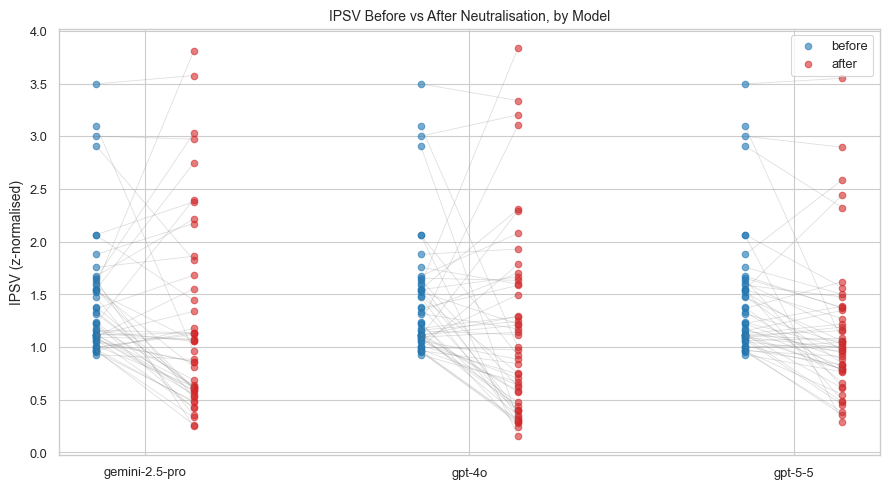

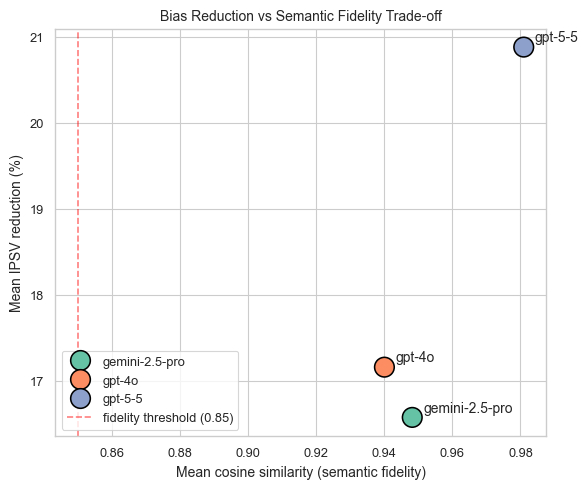

/var/folders/j9/vckttwzx3fl97tbtw2qy5fcr0000gn/T/ipykernel_96134/2208224783.py:66: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=cost_eff, x='model', y='mean_IPSV_reduction_pct',


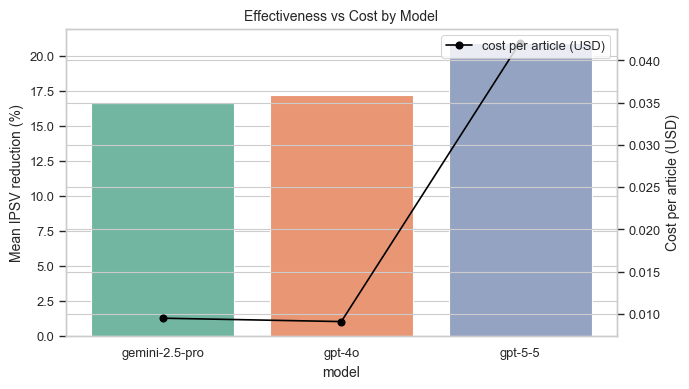

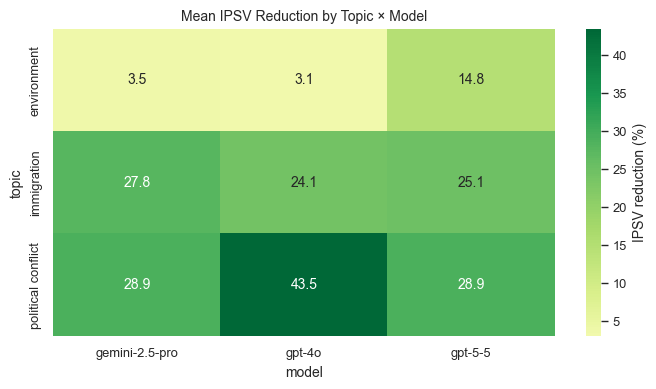

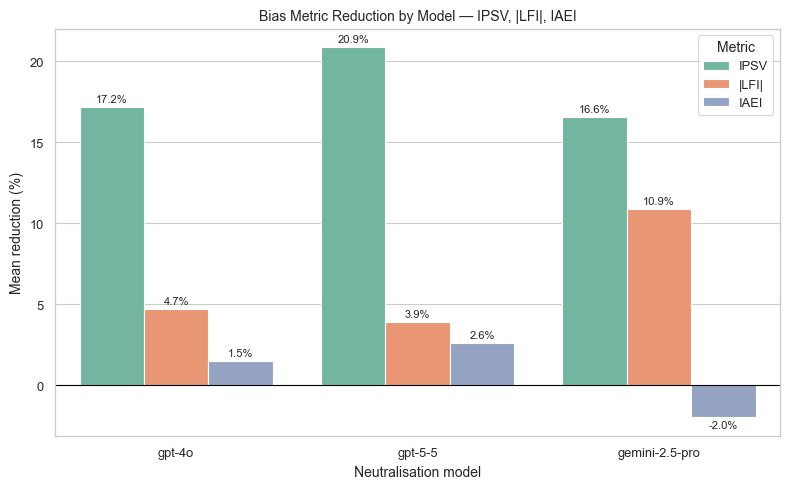

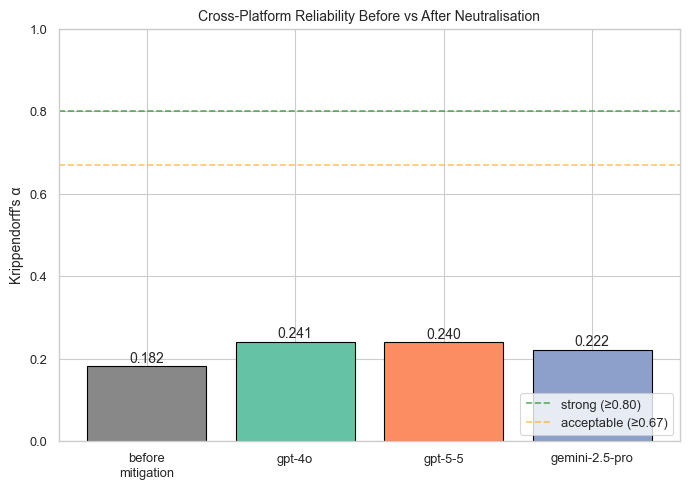

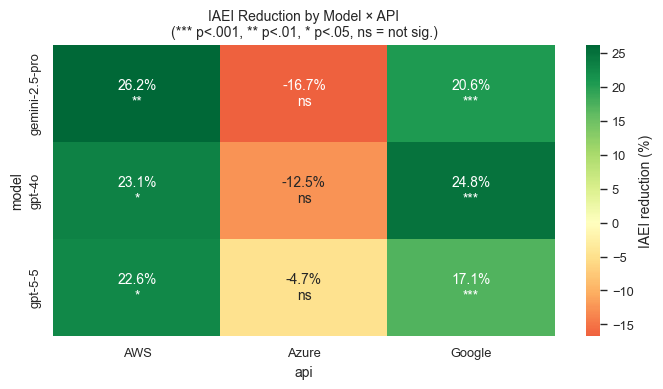

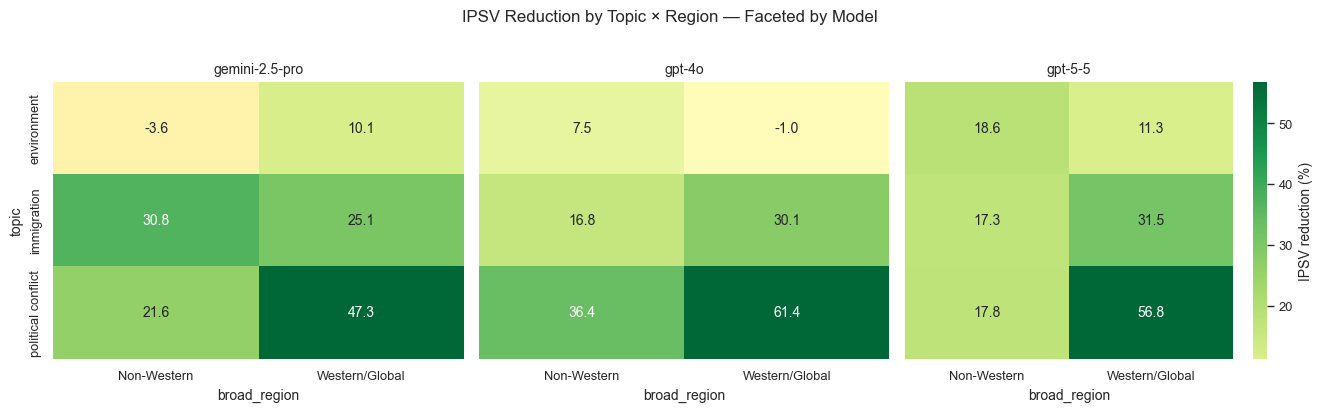

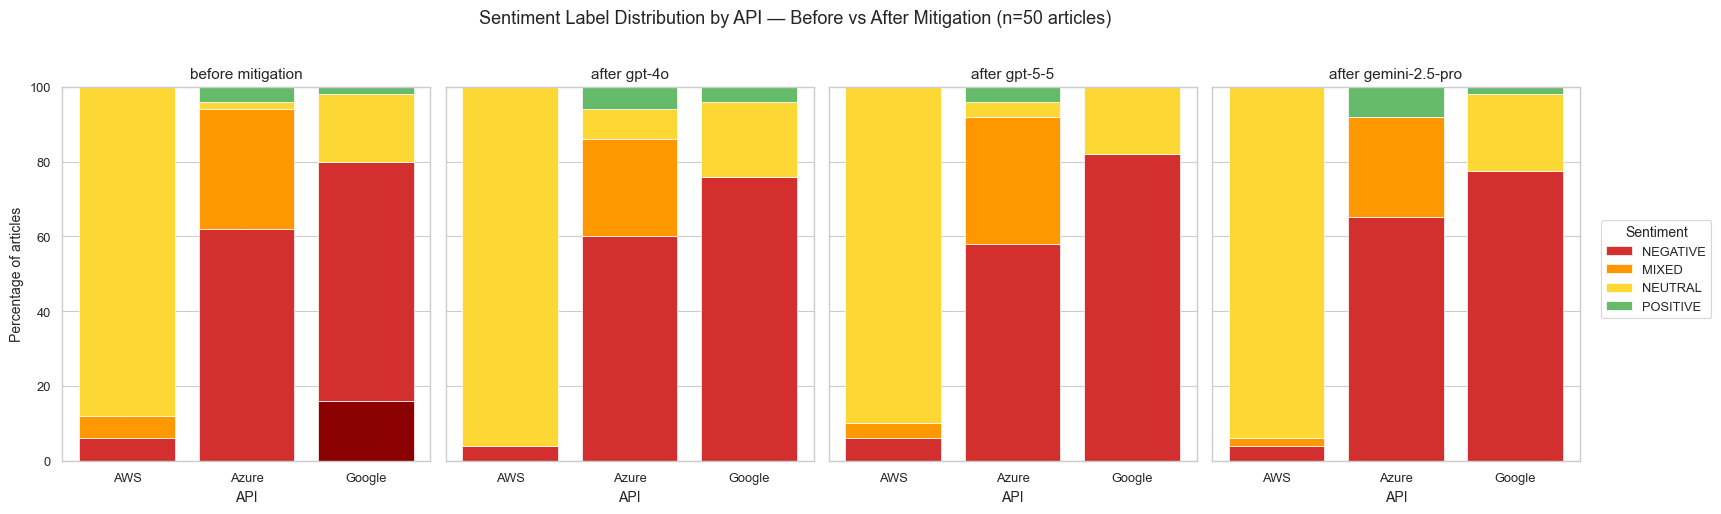

  Plus:     plot_label_distribution_before_after

✓ Plots saved to mitigation_results
  Existing: plot_ipsv_paired_by_model, plot_effectiveness_vs_fidelity,
            plot_cost_vs_effectiveness, plot_topic_model_heatmap
  New:      plot_unified_metric_reduction, plot_krippendorff_alpha,
            plot_iaei_heatmap, plot_region_topic_faceted


In [26]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('whitegrid')
sns.set_context('paper', font_scale=1.05)

# EXISTING PLOTS

# plot 1: IPSV before/after by model (paired)
fig, ax = plt.subplots(figsize=(9, 5))
for i, model_name in enumerate(comparison['model'].unique()):
    sub = comparison[comparison['model'] == model_name]
    x_b = np.full(len(sub), i*2 + 0.0)
    x_a = np.full(len(sub), i*2 + 0.6)
    for j in range(len(sub)):
        ax.plot([x_b[j], x_a[j]],
                [sub['IPSV_before'].iloc[j], sub['IPSV_after'].iloc[j]],
                color='gray', alpha=0.25, linewidth=0.6)
    ax.scatter(x_b, sub['IPSV_before'], alpha=0.6, s=22,
               label='before' if i == 0 else None, color='C0')
    ax.scatter(x_a, sub['IPSV_after'], alpha=0.6, s=22,
               label='after' if i == 0 else None, color='C3')
ax.set_xticks([i*2 + 0.3 for i in range(comparison['model'].nunique())])
ax.set_xticklabels(comparison['model'].unique())
ax.set_ylabel('IPSV (z-normalised)')
ax.set_title('IPSV Before vs After Neutralisation, by Model')
ax.legend()
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'plot_ipsv_paired_by_model.png'), dpi=150)
plt.show()

# plot 2: Effectiveness vs fidelity (scatter)
agg = (comparison.groupby('model')['IPSV_reduction_pct'].mean()
       .to_frame('reduction_pct')
       .join(df_fidelity.groupby('model')['cosine_similarity'].mean()
             .to_frame('fidelity'))
       .reset_index())

fig, ax = plt.subplots(figsize=(6, 5))
sns.scatterplot(data=agg, x='fidelity', y='reduction_pct',
                hue='model', s=200, ax=ax, palette='Set2', edgecolor='black')
for _, row in agg.iterrows():
    ax.annotate(row['model'], (row['fidelity'], row['reduction_pct']),
                xytext=(8, 4), textcoords='offset points', fontsize=10)
ax.axvline(COSINE_SIMILARITY_THRESHOLD, color='red', linestyle='--', alpha=0.5,
           label=f'fidelity threshold ({COSINE_SIMILARITY_THRESHOLD})')
ax.set_xlabel('Mean cosine similarity (semantic fidelity)')
ax.set_ylabel('Mean IPSV reduction (%)')
ax.set_title('Bias Reduction vs Semantic Fidelity Trade-off')
ax.legend(loc='lower left')
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'plot_effectiveness_vs_fidelity.png'), dpi=150)
plt.show()

# plot 3: Cost vs effectiveness
cost_eff = cost_benefit[['cost_per_article', 'mean_IPSV_reduction_pct']].reset_index()
fig, ax = plt.subplots(figsize=(7, 4))
sns.barplot(data=cost_eff, x='model', y='mean_IPSV_reduction_pct',
            ax=ax, palette='Set2')
ax2 = ax.twinx()
ax2.plot(cost_eff['model'], cost_eff['cost_per_article'],
         color='black', marker='o', label='cost per article (USD)')
ax.set_ylabel('Mean IPSV reduction (%)')
ax2.set_ylabel('Cost per article (USD)')
ax.set_title('Effectiveness vs Cost by Model')
ax2.legend(loc='upper right')
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'plot_cost_vs_effectiveness.png'), dpi=150)
plt.show()

# plot 4: Per-topic reduction × model (heatmap)
pivot = (comparison.groupby(['topic', 'model'])['IPSV_reduction_pct']
         .mean().unstack('model').round(1))
fig, ax = plt.subplots(figsize=(7, 4))
sns.heatmap(pivot, annot=True, fmt='.1f', cmap='RdYlGn', center=0,
            cbar_kws={'label': 'IPSV reduction (%)'}, ax=ax)
ax.set_title('Mean IPSV Reduction by Topic × Model')
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'plot_topic_model_heatmap.png'), dpi=150)
plt.show()

# NEW PLOTS - for LFI, IAEI, α, regional stratification

# helper: graceful CSV loader
def _load_if_exists(name):
    p = os.path.join(OUTPUT_DIR, name)
    return pd.read_csv(p) if os.path.exists(p) else None

# plot 5: Unified bias-metric reduction by model
# (the headline chart - IPSV, |LFI|, IAEI all in one)
df_lfi   = _load_if_exists('results_lfi_comparison.csv')
df_iaei  = _load_if_exists('results_iaei_comparison.csv')

unified_rows = []
for model_name in [m['name'] for m in MODELS]:
    sub_ipsv = comparison[comparison['model'] == model_name]
    if len(sub_ipsv) == 0: continue
    unified_rows.append({'model': model_name, 'metric': 'IPSV',
                         'reduction_pct': sub_ipsv['IPSV_reduction_pct'].mean()})
    if df_lfi is not None:
        sub = df_lfi[df_lfi['model'] == model_name]
        if sub['abs_lfi_before'].mean() > 0:
            unified_rows.append({
                'model': model_name, 'metric': '|LFI|',
                'reduction_pct': (sub['abs_lfi_before'].mean() - sub['abs_lfi_after'].mean())
                                 / sub['abs_lfi_before'].mean() * 100
            })
    if df_iaei is not None:
        sub = df_iaei[df_iaei['model'] == model_name]
        if sub['IAEI_before'].mean() > 0:
            unified_rows.append({
                'model': model_name, 'metric': 'IAEI',
                'reduction_pct': (sub['IAEI_before'].mean() - sub['IAEI_after'].mean())
                                 / sub['IAEI_before'].mean() * 100
            })

if unified_rows:
    df_unified = pd.DataFrame(unified_rows)
    fig, ax = plt.subplots(figsize=(8, 5))
    sns.barplot(data=df_unified, x='model', y='reduction_pct',
                hue='metric', palette='Set2', ax=ax)
    ax.axhline(0, color='black', linewidth=0.8)
    ax.set_ylabel('Mean reduction (%)')
    ax.set_xlabel('Neutralisation model')
    ax.set_title('Bias Metric Reduction by Model — IPSV, |LFI|, IAEI')
    ax.legend(title='Metric', loc='best')
    for container in ax.containers:
        ax.bar_label(container, fmt='%.1f%%', fontsize=8, padding=2)
    plt.tight_layout()
    plt.savefig(os.path.join(OUTPUT_DIR, 'plot_unified_metric_reduction.png'), dpi=150)
    plt.show()

# plot 6: Krippendorff's α before vs after with reliability thresholds
df_kripp = _load_if_exists('results_krippendorff_comparison.csv')

if df_kripp is not None:
    alpha_before_val = df_kripp[df_kripp['condition'] == 'before_mitigation']['alpha'].iloc[0]
    after_rows = df_kripp[df_kripp['condition'] == 'after_mitigation'][['model', 'alpha']]

    plot_df = pd.concat([
        pd.DataFrame([{'label': 'before\nmitigation', 'alpha': alpha_before_val}]),
        after_rows.rename(columns={'model': 'label'})
    ], ignore_index=True)

    fig, ax = plt.subplots(figsize=(7, 5))
    palette = ['#888888'] + sns.color_palette('Set2', n_colors=len(after_rows))
    bars = ax.bar(plot_df['label'], plot_df['alpha'], color=palette, edgecolor='black')
    ax.axhline(0.80, linestyle='--', color='green', alpha=0.6, label='strong (≥0.80)')
    ax.axhline(0.67, linestyle='--', color='orange', alpha=0.6, label='acceptable (≥0.67)')
    ax.set_ylabel("Krippendorff's α")
    ax.set_title("Cross-Platform Reliability Before vs After Neutralisation")
    ax.set_ylim(min(plot_df['alpha'].min() - 0.1, 0), max(1.0, plot_df['alpha'].max() + 0.05))
    for bar, val in zip(bars, plot_df['alpha']):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                f'{val:.3f}', ha='center', fontsize=10)
    ax.legend(loc='lower right')
    plt.tight_layout()
    plt.savefig(os.path.join(OUTPUT_DIR, 'plot_krippendorff_alpha.png'), dpi=150)
    plt.show()

# plot 7: IAEI heatmap - model × api with significance markers
df_iaei_tests = _load_if_exists('results_iaei_ttests.csv')

if df_iaei is not None and df_iaei_tests is not None:
    # pivot for IAEI reduction %
    iaei_red = (df_iaei.groupby(['model', 'api'])
                .apply(lambda g: 100 * (g['IAEI_before'].mean() - g['IAEI_after'].mean())
                                 / g['IAEI_before'].mean()
                                 if g['IAEI_before'].mean() > 0 else np.nan)
                .unstack('api').round(1))

    # build annotation matrix combining value + significance
    sig_lookup = {}
    for _, r in df_iaei_tests.iterrows():
        sig_lookup[(r['model'], r['api'])] = r.get('significance', 'ns')
    annot = iaei_red.copy().astype(str)
    for m in iaei_red.index:
        for a in iaei_red.columns:
            val = iaei_red.loc[m, a]
            if pd.isna(val):
                annot.loc[m, a] = ''
            else:
                sig = sig_lookup.get((m, a), '')
                annot.loc[m, a] = f'{val:.1f}%\n{sig}'

    fig, ax = plt.subplots(figsize=(7, 4))
    sns.heatmap(iaei_red, annot=annot, fmt='', cmap='RdYlGn', center=0,
                cbar_kws={'label': 'IAEI reduction (%)'}, ax=ax,
                annot_kws={'fontsize': 10})
    ax.set_title('IAEI Reduction by Model × API\n(*** p<.001, ** p<.01, * p<.05, ns = not sig.)')
    plt.tight_layout()
    plt.savefig(os.path.join(OUTPUT_DIR, 'plot_iaei_heatmap.png'), dpi=150)
    plt.show()

# plot 8: Region × topic IPSV reduction faceted by model
df_strat = _load_if_exists('results_stratified_comparison.csv')

if df_strat is not None and 'broad_region' in df_strat.columns:
    n_models = df_strat['model'].nunique()
    fig, axes = plt.subplots(1, n_models, figsize=(4.5 * n_models, 4),
                              sharey=True, squeeze=False)
    for ax_i, model_name in enumerate(sorted(df_strat['model'].unique())):
        sub = df_strat[df_strat['model'] == model_name]
        piv = (sub.groupby(['topic', 'broad_region'])['IPSV_reduction_pct']
               .mean().unstack('broad_region').round(1))
        sns.heatmap(piv, annot=True, fmt='.1f', cmap='RdYlGn', center=0,
                    cbar=(ax_i == n_models - 1),
                    cbar_kws={'label': 'IPSV reduction (%)'} if ax_i == n_models - 1 else None,
                    ax=axes[0, ax_i])
        axes[0, ax_i].set_title(model_name)
        if ax_i > 0:
            axes[0, ax_i].set_ylabel('')
    fig.suptitle('IPSV Reduction by Topic × Region — Faceted by Model', y=1.02)
    plt.tight_layout()
    plt.savefig(os.path.join(OUTPUT_DIR, 'plot_region_topic_faceted.png'), dpi=150,
                bbox_inches='tight')
    plt.show()

# plot 9: API label distribution - before vs after, per model
# discrete-level analog of the IPSV reduction story:
# do the APIs converge on the same categorical labels after mitigation?

mitigated_ids = df_neutralised['article_id'].unique()

before_lbl = (df_sentiment_orig[df_sentiment_orig['article_id'].isin(mitigated_ids)]
              [['article_id', 'api', 'sentiment_label']]
              .copy())
before_lbl['panel'] = 'before mitigation'

after_lbl = (df_sent_neut.rename(columns={'neutralisation_model': 'panel'})
             [['article_id', 'api', 'sentiment_label', 'panel']]
             .copy())
after_lbl['panel'] = 'after ' + after_lbl['panel']

label_data = pd.concat([before_lbl, after_lbl], ignore_index=True)

# consistent label ordering and colors (red → green sentiment polarity)
LABEL_ORDER = ['VERY_NEGATIVE', 'NEGATIVE', 'MIXED', 'NEUTRAL', 'POSITIVE', 'VERY_POSITIVE']
LABEL_COLORS = {
    'VERY_NEGATIVE': '#8B0000',   # dark red
    'NEGATIVE':      '#D32F2F',   # red
    'MIXED':         '#FF9800',   # orange
    'NEUTRAL':       '#FDD835',   # yellow
    'POSITIVE':      '#66BB6A',   # green
    'VERY_POSITIVE': '#2E7D32',   # dark green
}

panel_order = ['before mitigation'] + [f'after {m["name"]}' for m in MODELS]
panel_order = [p for p in panel_order if p in label_data['panel'].unique()]

n_panels = len(panel_order)
fig, axes = plt.subplots(1, n_panels, figsize=(4.0 * n_panels, 5),
                          sharey=True, squeeze=False)

for idx, panel in enumerate(panel_order):
    ax = axes[0, idx]
    sub = label_data[label_data['panel'] == panel]
    counts = sub.groupby(['api', 'sentiment_label']).size().unstack(fill_value=0)
    pct = counts.div(counts.sum(axis=1), axis=0) * 100
    cols_present = [c for c in LABEL_ORDER if c in pct.columns]
    pct = pct[cols_present]

    bottom = np.zeros(len(pct))
    for label in cols_present:
        ax.bar(pct.index, pct[label], bottom=bottom,
               color=LABEL_COLORS[label], edgecolor='white',
               linewidth=0.5, label=label)
        bottom += pct[label].values

    ax.set_title(panel, fontsize=11)
    ax.set_xlabel('API')
    if idx == 0:
        ax.set_ylabel('Percentage of articles')
    ax.set_ylim(0, 100)
    ax.set_yticks([0, 20, 40, 60, 80, 100])

# single legend in canonical sentiment order
handles, labels = axes[0, -1].get_legend_handles_labels()
order_map = {l: i for i, l in enumerate(LABEL_ORDER)}
sorted_pairs = sorted(zip(handles, labels), key=lambda x: order_map.get(x[1], 99))
handles, labels = zip(*sorted_pairs) if sorted_pairs else ([], [])
fig.legend(handles, labels, title='Sentiment', loc='center left',
           bbox_to_anchor=(1.0, 0.5), frameon=True)

fig.suptitle(f'Sentiment Label Distribution by API — Before vs After Mitigation '
             f'(n={len(mitigated_ids)} articles)',
             y=1.02, fontsize=13)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'plot_label_distribution_before_after.png'),
            dpi=150, bbox_inches='tight')
plt.show()

print('  Plus:     plot_label_distribution_before_after')

print('\n✓ Plots saved to', OUTPUT_DIR)
print('  Existing: plot_ipsv_paired_by_model, plot_effectiveness_vs_fidelity,')
print('            plot_cost_vs_effectiveness, plot_topic_model_heatmap')
print('  New:      plot_unified_metric_reduction, plot_krippendorff_alpha,')
print('            plot_iaei_heatmap, plot_region_topic_faceted')